---

# **Brazilian E-Commerce by Olist - Seller Churn Prediction**
---



## **1. Business Problem & Data Understanding**

### **a) Business Context**

Olist merupakan platform marketplace yang menghubungkan seller dengan pelanggan di Brasil. Keberlanjutan aktivitas seller penting bagi platform karena seller yang berhenti bertransaksi dapat mengurangi variasi produk, volume penjualan, dan potensi pendapatan marketplace.

Dalam project ini, seller churn didefinisikan sebagai seller yang telah berada di platform selama lebih dari 30 hari dan tidak melakukan transaksi selama minimal 30 hari sebelum tanggal referensi. Analisis ini berfokus pada identifikasi karakteristik dan pola aktivitas seller yang mengalami churn, sehingga Olist dapat mendeteksi seller berisiko lebih awal dan menyusun strategi retensi secara lebih tepat sasaran.


### **b) Problem Statement**

Dalam menjaga keberlangsungan pertumbuhan bisnis e-commerce, Olist dihadapkan pada tantangan untuk mengidentifikasi dan mencegah seller churn secara dini. Kehilangan seller yang aktif bertransaksi tidak hanya menggerus pendapatan berulang (recurring revenue), tetapi juga berdampak signifikan pada efisiensi biaya operasional perusahaan.

Berdasarkan kalkulasi bisnis, biaya tindakan pencegahan (preventive action) bernilai 1/5 lebih murah dibandingkan biaya reaktivasi atau retention setelah seller terlanjur pindah (churn).

Tanpa adanya model Machine Learning berbasis churn prediction yang akurat untuk menganalisis riwayat transaksi, aktivitas penjualan, dan performa seller, upaya pencegahan churn akan menjadi tidak tepat sasaran, sehingga menyebabkan pemborosan anggaran campaign untuk seller yang tidak berisiko, serta hilangnya potensi seller secara permanen akibat kegagalan deteksi dini.

### **c) Goals**

- Specific — Membangun model machine learning classification untuk memprediksi probabilitas churn seller e-commerce menggunakan berbagai fitur-fitur terkait.
- Measurable — Mencapai skor F2 $\ge$ [target, misal: 0,85] dan Recall $\ge$ [target, misal: 80%] pada data test, serta membuktikan penurunan churn rate atau penghematan biaya intervensi jika dibandingkan dengan strategi baseline tanpa model.
- Achievable — Memanfaatkan data historis transaksi Olist pada periode 2016 sampai 2018 yang mencakup profil pesanan, riwayat pembayaran, dan estimasi jarak lokasi seller-customer.
- Relevant — Output churn score digunakan oleh stakeholder (tim operasional olist) untuk melakukan tindakan pencegahan (preventive action) yang 5 kali lebih hemat dibandingkan biaya retention setelah seller terlanjur churn.
- Time-bound — Target project finish pada 2 Oktober 2026.

### **d) Analytic Approach**

Analisis dilakukan melalui tahapan data cleaning, exploratory data analysis, analisis faktor-faktor yang berkaitan dengan churn, feature engineering, serta pemodelan klasifikasi. Pada kelas churn, F2 Score dan recall digunakan sebagai metrik utama untuk meminimalkan seller churn yang gagal terdeteksi.

### **e) Metric Evaluation**
Dalam kasus churn ini, didefinisikan sebagai:
**Positive (1) = Churn** Sedangkan **Negative (0) = No Churn**

- True Positive (TP): Seller sebenarnya churn dan model juga memprediksi churn.
- False Positive (FP): Seller sebenarnya tidak churn, tetapi model memprediksi churn.
- False Negative (FN): Seller sebenarnya churn, tetapi model memprediksi tidak churn.
- True Negative(TN): Seller sebenarnya tidak churn dan model juga memprediksi tidak churn.
  
Dalam konteks bisnis, terdapat dua jenis kesalahan prediksi yang perlu diperhatikan, yaitu False Positive dan False Negative.

1. **False Positive (FP)**
Seller sebenarnya tidak churn, tetapi diprediksi berisiko churn sehingga mendapatkan promosi atau tindakan retensi. Hal ini dapat menyebabkan biaya promosi terbuang karena promosi diberikan kepada Seller yang sebenarnya masih akan bertahan.

2. **False Negative (FN)**
Seller sebenarnya churn, tetapi diprediksi tidak churn sehingga tidak mendapatkan promosi atau tindakan retensi. Kesalahan ini berpotensi menyebabkan kehilangan Seller dan pendapatan yang seharusnya masih dapat dipertahankan.

Berdasarkan penelitian Maan dan Maan., 2023 (https://arxiv.org/pdf/2303.00960), biaya untuk mendapatkan customer baru dapat mencapai sekitar 5 kali lebih besar dibandingkan biaya untuk mempertahankan customer yang sudah ada. Informasi tersebut digunakan dalam project ini sebagai dasar untuk menyusun business assumption, bukan sebagai biaya aktual perusahaan. Dengan menyesuaikan konteks pada seller, diasumsikan bahwa biaya akibat kehilangan seller yang sebenarnya churn tetapi tidak mendapatkan tindakan retensi (False Negative) adalah 5 kali lebih besar dibandingkan biaya pemberian tindakan retensi kepada seller yang sebenarnya tidak churn (False Positive)

Berdasarkan asumsi tersebut, FP dan FN sama-sama menimbulkan kerugian bagi perusahaan, tetapi dampaknya berbeda. FP menyebabkan pemborosan biaya promosi, sedangkan FN dapat menyebabkan kehilangan Seller beserta potensi pendapatan yang dihasilkan Seller tersebut. Dengan demikian, FN dianggap memiliki dampak bisnis yang lebih besar dibandingkan FP. Oleh karena itu, digunakan asumsi:
  - Biaya promo retensi: sebesar `$100`/Seller.
  - Potensi kerugian akibat kehilangan Seller: sebesar `$500`/Seller.

Oleh karena itu, model tetap perlu memperhatikan kedua jenis kesalahan, tetapi lebih memprioritaskan kemampuan model dalam mendeteksi Seller yang benar-benar akan churn, sehingga digunakan ***F2 Score***, yang memberikan bobot lebih besar pada Recall dibandingkan Precision. Dengan demikian, model lebih terdorong untuk meminimalkan FN, sehingga Seller yang berisiko churn dapat lebih banyak teridentifikasi dan diberikan tindakan retensi.

### **f) Data Olist**
Dataset yang digunakan merupakan data seller olist e-commerce dengan setiap baris merepresentasikan satu seller , sedangkan setiap kolom merepresentasikan karakteristik seller atau layanan yang digunakan. Target yang digunakan adalah `'Churn'`, yang menunjukkan apakah seller akan tidak aktif pada periode tertentu.

**Target**:
(Churn = 1, No Churn = 0)

#### Orders

| **Features**                  | **Description**                                        |
| ----------------------------- | ------------------------------------------------------ |
| order_id                      | ID unik untuk setiap pesanan                           |
| customer_id                   | ID unik customer yang melakukan pesanan                |
| order_status                  | Status pesanan                                         |
| order_purchase_timestamp      | Waktu ketika customer melakukan pemesanan              |
| order_approved_at             | Waktu ketika pembayaran pesanan disetujui              |
| order_delivered_carrier_date  | Waktu ketika pesanan diserahkan kepada pihak ekspedisi |
| order_delivered_customer_date | Waktu ketika pesanan diterima oleh customer            |
| order_estimated_delivery_date | Estimasi tanggal pesanan akan diterima customer        |

#### Customers

| **Features**             | **Description**                                                                                       |
| ------------------------ | ----------------------------------------------------------------------------------------------------- |
| customer_id              | ID customer untuk setiap pesanan                                                                 |
| customer_unique_id       | ID unik customer yang dapat digunakan untuk mengidentifikasi customer yang sama pada beberapa pesanan |
| customer_zip_code_prefix | Lima digit awal kode pos lokasi customer                                                              |
| customer_city            | Kota tempat customer berada                                                                           |
| customer_state           | Negara bagian/provinsi tempat customer berada                                                         |

#### Order Items

| **Features**        | **Description**                                         |
| ------------------- | ------------------------------------------------------- |
| order_id            | ID pesanan yang terkait dengan item                     |
| order_item_id       | Nomor urut item dalam satu pesanan                      |
| product_id          | ID unik produk                                          |
| seller_id           | ID unik seller yang menjual produk                      |
| shipping_limit_date | Batas waktu seller menyerahkan pesanan kepada ekspedisi |
| price               | Harga produk dalam pesanan                              |
| freight_value       | Biaya pengiriman untuk produk                           |

#### Payments

| **Features**         | **Description**                           |
| -------------------- | ----------------------------------------- |
| order_id             | ID pesanan yang terkait dengan pembayaran |
| payment_sequential   | Urutan pembayaran dalam satu pesanan      |
| payment_type         | Jenis metode pembayaran yang digunakan    |
| payment_installments | Jumlah cicilan pembayaran                 |
| payment_value        | Nilai pembayaran yang dilakukan customer  |

#### Reviews

| **Features**            | **Description**                                           |
| ----------------------- | --------------------------------------------------------- |
| review_id               | ID unik untuk setiap review                               |
| order_id                | ID pesanan yang diberikan review                          |
| review_score            | Skor penilaian customer terhadap pesanan, dari 1 hingga 5 |
| review_comment_title    | Judul komentar yang diberikan customer                    |
| review_comment_message  | Isi komentar atau ulasan dari customer                    |
| review_creation_date    | Tanggal review dibuat                                     |
| review_answer_timestamp | Waktu ketika review mendapatkan jawaban                   |

#### Products

| **Features**               | **Description**                        |
| -------------------------- | -------------------------------------- |
| product_id                 | ID unik produk                         |
| product_category_name      | Kategori produk dalam bahasa Portugis  |
| product_name_lenght        | Panjang nama produk                    |
| product_description_lenght | Panjang deskripsi produk               |
| product_photos_qty         | Jumlah foto yang tersedia untuk produk |
| product_weight_g           | Berat produk dalam gram                |
| product_length_cm          | Panjang produk dalam sentimeter        |
| product_height_cm          | Tinggi produk dalam sentimeter         |
| product_width_cm           | Lebar produk dalam sentimeter          |

#### Sellers

| **Features**           | **Description**                             |
| ---------------------- | ------------------------------------------- |
| seller_id              | ID unik seller                              |
| seller_zip_code_prefix | Lima digit awal kode pos lokasi seller      |
| seller_city            | Kota tempat seller berada                   |
| seller_state           | Negara bagian/provinsi tempat seller berada |

#### Geolocation

| **Features**                | **Description**                                     |
| --------------------------- | --------------------------------------------------- |
| geolocation_zip_code_prefix | Lima digit awal kode pos lokasi                     |
| geolocation_lat             | Koordinat lintang lokasi                            |
| geolocation_lng             | Koordinat bujur lokasi                              |
| geolocation_city            | Kota berdasarkan lokasi geografis                   |
| geolocation_state           | Negara bagian/provinsi berdasarkan lokasi geografis |

#### Category Translation

| **Features**                  | **Description**                                                 |
| ----------------------------- | --------------------------------------------------------------- |
| product_category_name         | Nama kategori produk dalam bahasa Portugis                      |
| product_category_name_english | Nama kategori produk yang telah diterjemahkan ke bahasa Inggris |




---


## **2. Import Modul**

In [1]:
pip install pandas-gbq

In [2]:
pip install category_encoders

In [3]:
pip install catboost

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pickle
import shap
import re
import duckdb
import pandas_gbq

from google.oauth2 import service_account
from google.cloud import bigquery

# Modul Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier,  RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier

# Modul untuk split data
from sklearn.model_selection import train_test_split

# Modul feature engineering (Encode, scaling, missing values, transformer & pipeline)
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.preprocessing import KBinsDiscretizer
from sklearn.preprocessing import PolynomialFeatures
import category_encoders as ce
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import VotingClassifier, StackingClassifier, BaggingClassifier, RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost.sklearn import XGBClassifier

# Cross Validation
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_validate
from sklearn.metrics import classification_report, confusion_matrix, fbeta_score

# Modul untuk metrics
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay, make_scorer, fbeta_score

# Resampling
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Handle warning
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows',  100)

---
## **3. Running Extract, Transform, Load (ETL)**

### **3.1 Load Dataset**

In [ ]:
df_produk           = pd.read_csv('/content/olist_products_dataset.csv')
df_order_item       = pd.read_csv('/content/olist_order_items_dataset.csv')
df_produk_kategori  = pd.read_csv('/content/product_category_name_translation.csv')
df_orders           = pd.read_csv('/content/olist_orders_dataset.csv')
df_customer         = pd.read_csv('/content/olist_customers_dataset.csv')
df_seller           = pd.read_csv('/content/olist_sellers_dataset.csv')
df_geolocation      = pd.read_csv('/content/olist_geolocation_dataset.csv')
df_payments         = pd.read_csv('/content/olist_order_payments_dataset.csv')
df_review           = pd.read_csv('/content/olist_order_reviews_dataset.csv')

In [ ]:
datasets = {'orders': df_orders, 'customers': df_customer, 'items': df_order_item,
            'payments': df_payments, 'reviews': df_review, 'products': df_produk,
            'sellers': df_seller, 'geolocation': df_geolocation,
            'category_translation': df_produk_kategori}

### **3.2 Pengecekan dan Handling Data**

#### **a) Cek Seluruh Dataset (Tipe data, missing value, duplikat)**

In [ ]:
for name, df in datasets.items():
    print("=" * 65)
    print(f"DATASET: {name}")
    print("=" * 65)
    print(pd.DataFrame({
            'column': df.columns,
            'dtype': df.dtypes.astype(str),
            'missing': df.isna().sum().values,
            'duplicates': df.duplicated().sum(),
            'unique': df.nunique().values
        }).to_string(index=False)
    )

    print()

DATASET: orders
                       column  dtype  missing  duplicates  unique
                     order_id object        0           0   99441
                  customer_id object        0           0   99441
                 order_status object        0           0       8
     order_purchase_timestamp object        0           0   98875
            order_approved_at object      160           0   90733
 order_delivered_carrier_date object     1783           0   81018
order_delivered_customer_date object     2965           0   95664
order_estimated_delivery_date object        0           0     459

DATASET: customers
                  column  dtype  missing  duplicates  unique
             customer_id object        0           0   99441
      customer_unique_id object        0           0   96096
customer_zip_code_prefix  int64        0           0   14994
           customer_city object        0           0    4119
          customer_state object        0           0      27

DAT

- Terdapat data tanggal yang masih belum sesuai format, maka data tersebut diformat ke format timestamp
- Terdapat duplikat pada dataset geolocation, maka data duplikat tersebut akan didrop.
- Terdapat null value pada product dan order dataset, maka null value pada product akan di drop sedangkan pada order tidak di drop karena bukan anomali pada data.

#### **b) Handling Date Type**

Mengubah data tanggal yang masih belum sesuai format datetime.

In [ ]:
def convert_timestamp(datasets):
    for df in datasets.values():
        for i in df.columns:
            if re.search(r'date|timestamp|approved', i, flags=re.IGNORECASE):
                df[i] = df[i].astype('timestamp[s][pyarrow]')

In [ ]:
convert_timestamp(datasets)

#### **c) Handling Missing Data**

Mengecek missing dan kesesuaian kategori produk dengan tabel translasi bahasa Inggris dan mengidentifikasi kategori yang belum memiliki terjemahan.

In [ ]:
products_df_group = df_produk['product_category_name'].value_counts(dropna=False).reset_index()
products_group_english_df = products_df_group.merge(df_produk_kategori, on='product_category_name', how='left')
products_group_english_df = products_group_english_df[['product_category_name', 'product_category_name_english', 'count']]
products_group_english_df[products_group_english_df['product_category_name_english'].isna()]

,product_category_name,product_category_name_english,count
17,NaN,NaN,610
67,portateis_cozinha_e_preparadores_de_alimentos,NaN,10
71,pc_gamer,NaN,3


Terdapat 2 produk kategori yang belum memilki terjemahan (dilakukan imputasi manual) dan 610 dataset tidak memiliki nama produk sehingga baris nan akan didrop

In [ ]:
missing_product_english = products_group_english_df[products_group_english_df['product_category_name_english'].isna()][['product_category_name']].dropna()
missing_product_english['product_category_name_english'] = ['kitchen_appliances_and_food_prep', 'pc_games']
df_produk_kategori = pd.concat([df_produk_kategori, missing_product_english])
df_produk_kategori

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
5,esporte_lazer,sports_leisure
6,perfumaria,perfumery
7,utilidades_domesticas,housewares
8,telefonia,telephony
9,relogios_presentes,watches_gifts


In [ ]:
df_produk.dropna(subset=['product_category_name','product_weight_g'], inplace=True)

#### **d) Handling Duplicate Data**

Terdapat 261831 data duplikasi pada geolocation, sehingga harus di drop.

In [ ]:
df_geolocation = df_geolocation.drop_duplicates()

#### **e) Handling Data Anomali**

Memastikan dataset hanya berlokasi di dalam batas administrasi Brazil, sehingga data lokasi yang tidak sesuai akan didrop.

In [ ]:
duckdb.sql('INSTALL SPATIAL; LOAD SPATIAL;')

In [ ]:
query = """
WITH geolocation_db AS (
SELECT
    geolocation_zip_code_prefix,
    geolocation_city,
    geolocation_state,
    ST_Point(geolocation_lng, geolocation_lat) AS geometry
FROM
    df_geolocation
)

, brazil_boundary AS (
SELECT
    * EXCLUDE(geom),
    ST_GeomFromText(ST_AsText(geom)) AS geometry
FROM
    ST_Read('/content/geoBoundaries-BRA-ADM0.geojson')
)

, geolocation_clean_db AS (
SELECT
    a.geolocation_zip_code_prefix,
    a.geolocation_city,
    a.geolocation_state,
    ST_Y(a.geometry) AS latitude,
    ST_X(a.geometry) AS longitude
FROM
    geolocation_db AS a
INNER JOIN
    brazil_boundary AS b
ON
    ST_Within(a.geometry, b.geometry)
)

SELECT
    geolocation_zip_code_prefix,
    MEDIAN(latitude) AS geolocation_lat,
    MEDIAN(longitude) AS geolocation_lng,
    MODE(strip_accents(geolocation_city)) AS geolocation_city,
    MODE(geolocation_state) AS geolocation_state
FROM
    geolocation_clean_db
GROUP BY 1
ORDER BY 1 ASC
"""

df_geolocation = duckdb.sql(query).to_df()
df_geolocation

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1001,-23.549951,-46.634027,sao paulo,SP
1,1002,-23.548228,-46.635247,sao paulo,SP
2,1003,-23.548977,-46.635313,sao paulo,SP
3,1004,-23.549550,-46.634771,sao paulo,SP
4,1005,-23.549763,-46.636100,sao paulo,SP
...,...,...,...,...,...
19006,99960,-27.953797,-52.029641,charrua,RS
19007,99965,-28.179542,-52.035551,agua santa,RS
19008,99970,-28.343257,-51.875470,ciriaco,RS
19009,99980,-28.388342,-51.846871,david canabarro,RS


Menghapus kolom city dan state pada data seller karena informasi lokasi telah tersedia pada dataset geolocation.

In [ ]:
df_seller = df_seller.drop(columns=['seller_city', 'seller_state'])
df_seller

,seller_id,seller_zip_code_prefix
0,3442f8959a84dea7ee197c632cb2df15,13023
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195
4,51a04a8a6bdcb23deccc82b0b80742cf,12914
...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111
3091,f8201cab383e484733266d1906e2fdfa,88137
3092,74871d19219c7d518d0090283e03c137,4650
3093,e603cf3fec55f8697c9059638d6c8eb5,96080


Menghapus kolom city dan state pada data customer karena informasi lokasi telah tersedia pada dataset geolocation.

In [ ]:
df_customer = df_customer.drop(columns=['customer_city', 'customer_state'])
df_customer

,customer_id,customer_unique_id,customer_zip_code_prefix
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056
...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120


#### **f) Pengecekan Data Setelah Handling**

Update data terlebih dahulu datasets yang sudah dihandling.

In [ ]:
datasets = {'orders': df_orders, 'customers': df_customer, 'items': df_order_item,
            'payments': df_payments, 'reviews': df_review, 'products': df_produk,
            'sellers': df_seller, 'geolocation': df_geolocation,
            'category_translation': df_produk_kategori}

In [ ]:
for name, df in datasets.items():
    print("=" * 65)
    print(f"DATASET: {name}")
    print("=" * 65)
    print(pd.DataFrame({
            'column': df.columns,
            'dtype': df.dtypes.astype(str),
            'missing': df.isna().sum().values,
            'duplicates': df.duplicated().sum(),
            'unique': df.nunique().values
        }).to_string(index=False)
    )

    print()

DATASET: orders
                       column                 dtype  missing  duplicates  unique
                     order_id                object        0           0   99441
                  customer_id                object        0           0   99441
                 order_status                object        0           0       8
     order_purchase_timestamp timestamp[s][pyarrow]        0           0   98875
            order_approved_at        datetime64[ns]      160           0   90733
 order_delivered_carrier_date timestamp[s][pyarrow]     1783           0   81018
order_delivered_customer_date timestamp[s][pyarrow]     2965           0   95664
order_estimated_delivery_date timestamp[s][pyarrow]        0           0     459

DATASET: customers
                  column  dtype  missing  duplicates  unique
             customer_id object        0           0   99441
      customer_unique_id object        0           0   96096
customer_zip_code_prefix  int64        0           0

#### **g) BigQuery Configurations**

Mengunggah data ke BigQuery setelah melalui proses handling.

In [ ]:
key_path = '/content/dataset-analytics-01-6ab2a1ebe2de.json'

scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    key_path,
    scopes=scopes
)

project_id = 'dataset-analytics-01'
dataset_id = 'data_olist_clean'

client = bigquery.Client(project=project_id, credentials=credentials)

job_config = bigquery.LoadJobConfig(
    write_disposition='WRITE_APPEND'
)

dataset = bigquery.Dataset(f'{project_id}.{dataset_id}')
client.create_dataset(dataset)

Dataset(DatasetReference('capstone-m2', 'data_olist'))

In [ ]:
ingest_tables = {
    'products':             df_produk,
    'products_category':    df_produk_kategori,
    'reviews':              df_review,
    'geolocation':          df_geolocation,
    'customers':            df_customer,
    'sellers':              df_seller,
    'items':                df_order_item,
    'orders':               df_orders,
    'payments':             df_payments
}

def dump_ingest_bigquery(ingest_tables):
    for table_name, df in ingest_tables.items():
        table_id = f"{project_id}.{dataset_id}.{table_name}"
        job_config = bigquery.LoadJobConfig(
            autodetect=True,
            write_disposition="WRITE_TRUNCATE",
        )

        job = client.load_table_from_dataframe(df, table_id, job_config=job_config)
        job.result()
        print(f'done ingested {table_name}')

In [ ]:
dump_ingest_bigquery(ingest_tables)

done ingested products
done ingested products_category
done ingested reviews
done ingested geolocation
done ingested customers
done ingested sellers
done ingested items
done ingested orders
done ingested payments


### **3.3 Data Retrieval from BiqQuery**

Load data yang sudah clean dari BigQuery.

In [5]:
key_path = '/content/dataset-analytics-01-6ab2a1ebe2de.json'

scopes = ["https://www.googleapis.com/auth/bigquery"]
credentials = service_account.Credentials.from_service_account_file(
    key_path,
    scopes=scopes
)

project_id = 'dataset-analytics-01'
dataset_id = 'data_olist_clean'

client = bigquery.Client(
    project=project_id,
    credentials=credentials
)

tables = client.list_tables(dataset_id)

for table in tables:
    print(table.table_id)

customers
data_olist_clean_merge
geolocation
order_items
orders
payments
products
products_category
reviews
sellers


In [6]:
table_names = [
    'products',
    'products_category',
    'reviews',
    'geolocation',
    'customers',
    'sellers',
    'order_items',
    'orders',
    'payments'
]

datasets = {}

for table in table_names:
    sql_query = f"""
    SELECT *
    FROM `{project_id}.{dataset_id}.{table}`
    """

    datasets[table] = pandas_gbq.read_gbq(
        sql_query,
        project_id=project_id,
        credentials=credentials
    )

Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|
Downloading: 100%|██████████|


In [7]:
df_orders = datasets['orders']
df_customer = datasets['customers']
df_order_item = datasets['order_items']
df_payments = datasets['payments']
df_review = datasets['reviews']
df_produk = datasets['products']
df_seller = datasets['sellers']
df_geolocation = datasets['geolocation']
df_kategori = datasets['products_category']

---
## **6. Definisi Target dan Labeling**

### **a) Membuat Cutoff Date**

Melihat rentang data.

In [8]:
print("Start:",df_orders['order_delivered_carrier_date'].min())
print("End:",df_orders['order_delivered_carrier_date'].max())

Start: 2016-10-08 10:34:01
End: 2018-09-11 19:48:28


Cutoff date ditetapkan 30 hari sebelum tanggal terakhir pengiriman order ke carrier pada dataset. Periode 30 hari digunakan sebagai batas waktu untuk membedakan seller yang masih aktif dengan seller yang tidak menunjukkan aktivitas selama periode pengamatan. Pemilihan 30 hari didasarkan pada periode satu bulan yang relatif sederhana dan mudah diinterpretasikan sebagai jangka waktu aktivitas seller.

In [9]:
cutoff_date = (
    df_orders.loc[
        df_orders['order_delivered_carrier_date'].notna(),
        'order_delivered_carrier_date'].max() - pd.Timedelta(days=30))
cutoff_date

Timestamp('2018-08-12 19:48:28')

### **b) Data Dasar untuk Pelabelan Churn**

Menggabungkan data seller, order item, dan informasi tanggal pengiriman ke carrier untuk membentuk data dasar aktivitas seller yang digunakan dalam penentuan eligibility dan pelabelan status churn.

In [10]:
df_orders_valid = df_orders[df_orders['order_delivered_carrier_date'].notna()].copy()

df_order_data = df_seller[['seller_id']].merge(
    df_order_item[['seller_id', 'order_id']],
    on='seller_id',
    how='left'
)

df_order_data = df_order_data.merge(df_orders_valid[['order_id', 'order_delivered_carrier_date']],
    on='order_id',
    how='left'
)

### **c) Agregasi Seller untuk Pelabelan Churn**

Mengagregasikan data pada tingkat seller untuk memperoleh jumlah order valid (total_orders), tanggal aktivitas pertama (min_order_delivered_carrier_date), dan tanggal aktivitas terakhir (max_order_delivered_carrier_date) sebagai dasar penentuan status churn.

In [11]:
df_order_data = (
    df_order_data
    .assign(delivered_order_id=df_order_data['order_id'].where(df_order_data['order_delivered_carrier_date'].notna()))
    .groupby('seller_id', as_index=False)
    .agg(
        total_order=('delivered_order_id', 'nunique'),
        min_order_delivered_carrier_date=('order_delivered_carrier_date', 'min'),
        max_order_delivered_carrier_date=('order_delivered_carrier_date', 'max'),
    )
)

df_order_data.head()

,seller_id,total_order,min_order_delivered_carrier_date,max_order_delivered_carrier_date
0,0015a82c2db000af6aaaf3ae2ecb0532,3,2017-09-29 15:53:03,2017-10-20 14:29:01
1,001cca7ae9ae17fb1caed9dfb1094831,200,2017-02-10 09:24:35,2018-07-13 13:32:00
2,001e6ad469a905060d959994f1b41e4f,0,NaT,NaT
3,002100f778ceb8431b7a1020ff7ab48f,51,2017-09-15 19:26:09,2018-04-12 23:11:48
4,003554e2dce176b5555353e4f3555ac8,1,2017-12-15 19:45:04,2017-12-15 19:45:04


Interpretasi df_order_data:

Seller 0015a82c2db000af6aaaf3ae2ecb0532 memiliki total 3 order yang tercatat memiliki tanggal pengiriman ke carrier. Aktivitas pengiriman pertama tercatat pada 29 September 2017 pukul 15:53:03, sedangkan aktivitas terakhir tercatat pada 20 Oktober 2017 pukul 14:29:01.

### **d) Labeling Target (Churn)**

Menentukan status churn setiap seller berdasarkan jumlah order dan aktivitas terakhir terhadap cutoff date, kemudian menghitung jumlah dan persentase seller pada setiap kategori status.

Kategori yang dihasilkan:
- not eligible → seller tidak memiliki order atau aktivitasnya belum memenuhi periode pengamatan (dibawah 30 hari). Untuk kategori ini tidak masuk kedalam proses modeling sehingga akan didrop.
- no churn → seller masih memiliki aktivitas hingga atau setelah cutoff date.
- churn → seller tidak menunjukkan aktivitas hingga batas waktu yang ditentukan. (>= 30 hari)

In [13]:
df_labeling = df_order_data.copy()

df_labeling['cutoff_date'] = cutoff_date

df_labeling['churn_status'] = np.select(
    [
        df_labeling['total_order'] == 0,
        df_labeling['min_order_delivered_carrier_date'] >= (cutoff_date - pd.Timedelta(days=30)),
        df_labeling['max_order_delivered_carrier_date'] >= cutoff_date
    ],
    [
        'not eligible',
        'not eligible',
        'no churn'
    ],
    default='churn'
)

df_labeling = df_labeling[['seller_id', 'churn_status']]

In [14]:
df_summary = (
    df_labeling
    .groupby('churn_status')
    .size()
    .reset_index(name='total')
)

df_summary['percentage'] = (
    df_summary['total'] / df_summary['total'].sum() * 100
)

df_summary

,churn_status,total,percentage
0,churn,1818,58.739903
1,no churn,874,28.239095
2,not eligible,403,13.021002


---
## **7. Data Integration**

### **a) Membuat df_seller_orders untuk Aktivitas Seller**

`df_seller_orders` dibuat sebagai tabel dasar yang menghubungkan **`seller_id` dengan `order_id` dan tanggal order**. Karena `df_order_item` berada pada level item, digunakan `drop_duplicates()` pada kombinasi `seller_id` dan `order_id` agar setiap seller-order hanya dihitung satu kali. Selanjutnya, `merge()` digunakan untuk menambahkan `order_delivered_carrier_date` dari `df_orders`. Tabel ini kemudian menjadi dasar untuk menghitung fitur aktivitas seller sebelum `cutoff date`, seperti `total_orders`, `seller_activity_duration_days`, dan `days_since_last_order`.


In [15]:
df_seller_orders = (df_order_item[['order_id', 'seller_id']].drop_duplicates().merge(
        df_orders[['order_id', 'order_delivered_carrier_date']],
        on='order_id',
        how='left'
    )
)

In [16]:
df_seller_orders = (
    df_seller_orders[df_seller_orders['order_delivered_carrier_date'].notna()]
    .sort_values(['seller_id', 'order_delivered_carrier_date'])
    .reset_index(drop=True)
)

In [17]:
df_seller_orders

,order_id,seller_id,order_delivered_carrier_date
0,d455a8cb295653b55abda06d434ab492,0015a82c2db000af6aaaf3ae2ecb0532,2017-09-29 15:53:03
1,9dc8d1a6f16f1b89874c29c9d8d30447,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-17 15:42:42
2,7f39ba4c9052be115350065d07583cac,0015a82c2db000af6aaaf3ae2ecb0532,2017-10-20 14:29:01
3,3c655487f0c8e34cde2c7b67de8f08cc,001cca7ae9ae17fb1caed9dfb1094831,2017-02-10 09:24:35
4,eb188a175542057d90b3ca5628b7b5a0,001cca7ae9ae17fb1caed9dfb1094831,2017-02-21 07:07:39
...,...,...,...
98995,fdb3ef83ea6f7bef7d13bdd9b38da661,ffff564a4f9085cd26170f4732393726,2017-01-24 14:49:32
98996,df537c849af44beef86a7ef7de12126a,ffff564a4f9085cd26170f4732393726,2017-01-25 16:05:15
98997,81251f18621a822ad5b09593dfee4fc9,ffff564a4f9085cd26170f4732393726,2017-01-25 16:51:53
98998,94b35c9542f07ad80b3367f9051b63af,ffff564a4f9085cd26170f4732393726,2017-01-26 16:32:31


### **b) Integrasi Dataset **Orders** sebelum Cutoff Date**

**Seller Activity** adalah dataset dengan satu baris untuk setiap seller yang berisi ringkasan aktivitas seller berdasarkan data yang tersedia hingga `cutoff_date`, dengan seller berstatus **not eligible** dikeluarkan dari dataset.


In [18]:
df_labeling = df_labeling[df_labeling['churn_status'] != 'not eligible'].copy()
len(df_labeling)

2692

| Fitur           | Sumber | Definisi                     |
| ------------------------ | ------ | ----------------------------------- |
| `total_orders`           | Orders | Jumlah order yang telah dikirimkan kepada kurir                 |
| `order_frequency`        | Orders | Intensitas/frekuensi order          |
| `avg_gap_antar_order`    | Orders | Rata-rata jeda antar-order          |
| `median_gap_antar_order` | Orders | Median jeda antar-order            |
| `max_gap_antar_order`    | Orders | Jeda terpanjang yang pernah terjadi |
| `total_active_order_days` | Orders | Jumlah hari seller mendapatkan order  |
| `total_active_order_months`          | Orders | Jumlah bulan seller mendapatkan order           |
| `first_order`  | Orders | Tanggal order pertama     |
| `last_order`     | Orders | Tanggal order terakhir      |
| `seller_activity_duration_days`         | Orders | Lama aktivitas seller sejak order pertama         |
| `days_since_last_order`         | Orders | Jarak hari sejak order terakhir seller hingga akhir periode observasi         |




In [20]:
df_hist = df_seller_orders[df_seller_orders['order_delivered_carrier_date'] <= cutoff_date].copy()
df_hist = df_hist.drop_duplicates(subset=['seller_id', 'order_id'])

In [21]:
eligible_sellers = df_labeling['seller_id'].unique()
df_hist = df_hist[df_hist['seller_id'].isin(eligible_sellers)].copy()

Membuat fitur first_order, last_order, dan total_orders.

In [22]:
seller_activity = (
    df_hist
    .groupby('seller_id')
    .agg(
        first_order=(
            'order_delivered_carrier_date',
            'min'
        ),
        last_order=(
            'order_delivered_carrier_date',
            'max'
        ),
        total_orders=(
            'order_id',
            'nunique'
        )
    )
    .reset_index()
)

Membuat seller_activity_duration_days untuk mengetahui berapa lama periode aktivitas seller.

In [23]:
seller_activity['seller_activity_duration_days'] = (cutoff_date - seller_activity['first_order']).dt.total_seconds() / (24 * 60 * 60)

Membuat fitur day_since_last_order untuk mengetahui jarak hari sejak order terakhir seller hingga akhir periode observasi.

In [24]:
seller_activity['days_since_last_order'] = (cutoff_date - seller_activity['last_order']).dt.total_seconds() / (24 * 60 * 60)

Membuat fitur order_frequency untuk mengetahui seberapa sering order dalam periode hingga cutoff date.

In [25]:
seller_activity['order_frequency'] = (seller_activity['total_orders'] / seller_activity['seller_activity_duration_days'])

In [26]:
df_hist = df_hist.sort_values(['seller_id', 'order_delivered_carrier_date']).reset_index(drop=True)

Membuat fitur gap_antar_order yang digunakan untuk menghitung jarak waktu antarorder yang dilakukan oleh seller. Perhitungan dilakukan berdasarkan urutan tanggal order untuk setiap seller_id, sehingga fitur ini menunjukkan berapa hari sejak order sebelumnya ke order berikutnya.

In [27]:
df_hist['gap_antar_order'] = (df_hist.groupby('seller_id')['order_delivered_carrier_date'].diff().dt.total_seconds() / (24 * 60 * 60))

In [28]:
gap_features = (
    df_hist
    .groupby('seller_id')
    .agg(avg_gap_antar_order=('gap_antar_order','mean'),
        median_gap_antar_order=(
            'gap_antar_order',
            'median'),
        max_gap_antar_order=(
            'gap_antar_order',
            'max'))
    .reset_index()
)

In [29]:
seller_activity = seller_activity.merge(
    gap_features,
    on='seller_id',
    how='left'
)

Fitur ini digunakan untuk mengetahui berapa banyak hari seller benar-benar mendapatkan order.

In [30]:
total_active_order_days = (
    df_hist
    .assign(
        order_date=df_hist[
            'order_delivered_carrier_date'
        ].dt.date
    )
    .groupby('seller_id')
    .agg(
        total_active_order_days=('order_date', 'nunique')
    )
    .reset_index()
)

In [31]:
seller_activity = seller_activity.merge(
    total_active_order_days,
    on='seller_id',
    how='left'
)

In [32]:
df_hist['order_month'] = (
    df_hist['order_delivered_carrier_date']
    .dt.to_period('M')
)

total_active_order_months = (
    df_hist
    .groupby('seller_id')
    .agg(total_active_order_months=('order_month', 'nunique'))
    .reset_index()
)

In [33]:
seller_activity = seller_activity.merge(
    total_active_order_months,
    on='seller_id',
    how='left'
)

In [34]:
df_model = df_labeling.merge(
    seller_activity,
    on='seller_id',
    how='left',
    validate='one_to_one'
)

In [35]:
df_model.head()

,seller_id,churn_status,first_order,last_order,total_orders,seller_activity_duration_days,days_since_last_order,order_frequency,avg_gap_antar_order,median_gap_antar_order,max_gap_antar_order,total_active_order_days,total_active_order_months
0,0015a82c2db000af6aaaf3ae2ecb0532,churn,2017-09-29 15:53:03,2017-10-20 14:29:01,3,317.163484,296.221840,0.009459,10.470822,10.470822,17.992812,3,2
1,001cca7ae9ae17fb1caed9dfb1094831,churn,2017-02-10 09:24:35,2018-07-13 13:32:00,200,548.433252,30.261435,0.364675,2.603878,1.059618,42.975694,126,17
2,002100f778ceb8431b7a1020ff7ab48f,churn,2017-09-15 19:26:09,2018-04-12 23:11:48,51,331.015498,121.858796,0.154071,4.183134,2.539369,28.180417,39,8
3,003554e2dce176b5555353e4f3555ac8,churn,2017-12-15 19:45:04,2017-12-15 19:45:04,1,240.002361,240.002361,0.004167,NaN,NaN,NaN,1,1
4,004c9cd9d87a3c30c522c48c4fc07416,churn,2017-01-30 10:18:21,2018-05-07 16:31:00,158,559.395914,97.137130,0.282448,2.944323,1.864815,19.239248,111,17


In [36]:
print('Jumlah seller di df_labeling :',
      df_labeling['seller_id'].nunique())

print('Jumlah seller di seller_activity :',
      seller_activity['seller_id'].nunique())

print('Jumlah baris seller_activity :',
      len(seller_activity))

Jumlah seller di df_labeling : 2692
Jumlah seller di seller_activity : 2692
Jumlah baris seller_activity : 2692


In [37]:
print("Jumlah seller sebelum merge :", len(seller_activity))
print("Jumlah seller setelah merge :", len(df_model))
print("Jumlah seller unik          :", df_model['seller_id'].nunique())

print("\nMissing value:")
print(df_model.isna().sum())

print("\nDistribusi churn:")
print(df_model['churn_status'].value_counts())

print("\nProporsi churn (%):")
print(
    df_model['churn_status']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Jumlah seller sebelum merge : 2692
Jumlah seller setelah merge : 2692
Jumlah seller unik          : 2692

Missing value:
seller_id                          0
churn_status                       0
first_order                        0
last_order                         0
total_orders                       0
seller_activity_duration_days      0
days_since_last_order              0
order_frequency                    0
avg_gap_antar_order              435
median_gap_antar_order           435
max_gap_antar_order              435
total_active_order_days            0
total_active_order_months          0
dtype: int64

Distribusi churn:
churn_status
churn       1818
no churn     874
Name: count, dtype: int64

Proporsi churn (%):
churn_status
churn       67.53
no churn    32.47
Name: proportion, dtype: float64


fitur gap_antar_order memiliki satu nilai NaN karena pada order pertamanya tidak terdapat order sebelumnya yang dapat digunakan untuk menghitung selisih waktu. Nilai NaN tersebut merupakan hasil yang wajar dari penggunaan diff().

### **c) Integrasi Dataset Historical **Orders Items** sebelum Cutoff Date**

In [38]:
df_order_item.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [39]:
df_order_item.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,3ee6513ae7ea23bdfab5b9ab60bffcb5,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-04 03:55:26,0.85,18.23
1,6e864b3f0ec71031117ad4cf46b7f2a1,1,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-02 20:30:34,0.85,18.23
2,c5bdd8ef3c0ec420232e668302179113,2,8a3254bee785a526d548a81a9bc3c9be,96804ea39d96eb908e7c3afdb671bb9e,2018-05-07 02:55:22,0.85,22.30
3,8272b63d03f5f79c56e9e4120aec44ef,2,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89
4,8272b63d03f5f79c56e9e4120aec44ef,3,05b515fdc76e888aada3c6d66c201dff,2709af9587499e95e803a6498a5a56e9,2017-07-21 18:25:23,1.20,7.89


| Fitur                  | Definisi                            |
| ---------------------- | ----------------------------------- |
| `total_items`          | Jumlah item dalam seluruh order     |
| `unique_products`      | Jumlah produk unik yang terjual     |
| `total_product_price`  | Total harga produk                  |
| `avg_product_price`    | Rata-rata harga produk              |
| `median_product_price` | Median harga produk                 |
| `min_product_price`    | Harga produk terendah               |
| `max_product_price`    | Harga produk tertinggi              |
| `total_freight_value`  | Total biaya pengiriman              |
| `avg_freight_value`    | Rata-rata biaya pengiriman          |
| `median_freight_value` | Median biaya pengiriman             |


In [40]:
df_orders_hist = df_orders[df_orders['order_delivered_carrier_date'] <= cutoff_date].copy()

In [41]:
df_order_item_hist = df_order_item.merge(
    df_orders_hist[['order_id']],
    on='order_id',
    how='inner'
)

In [42]:
print("Rows:", len(df_order_item_hist))
print("Unique orders:", df_order_item_hist['order_id'].nunique())
print("Unique sellers:", df_order_item_hist['seller_id'].nunique())

Rows: 106925
Unique orders: 93620
Unique sellers: 2883


In [43]:
order_item_features = (
    df_order_item_hist
    .groupby('seller_id')
    .agg(
        total_items=('order_item_id', 'count'),
        unique_products=('product_id', 'nunique'),
        total_product_price=('price', 'sum'),
        avg_product_price=('price', 'mean'),
        median_product_price=('price', 'median'),
        min_product_price=('price', 'min'),
        max_product_price=('price', 'max'),
        total_freight_value=('freight_value', 'sum'),
        avg_freight_value=('freight_value', 'mean'),
        median_freight_value=('freight_value', 'median')
    )
    .reset_index()
)

order_item_features.head()

,seller_id,total_items,unique_products,total_product_price,avg_product_price,median_product_price,min_product_price,max_product_price,total_freight_value,avg_freight_value,median_freight_value
0,0015a82c2db000af6aaaf3ae2ecb0532,3,1,2685.00,895.000000,895.00,895.0,895.00,63.06,21.020000,21.02
1,001cca7ae9ae17fb1caed9dfb1094831,239,11,25080.03,104.937364,99.00,69.9,199.00,8854.14,37.046611,36.85
2,002100f778ceb8431b7a1020ff7ab48f,55,24,1234.50,22.445455,17.90,9.9,129.90,793.66,14.430182,15.10
3,003554e2dce176b5555353e4f3555ac8,1,1,120.00,120.000000,120.00,120.0,120.00,19.38,19.380000,19.38
4,004c9cd9d87a3c30c522c48c4fc07416,170,88,19712.71,115.957118,109.99,47.9,259.99,3551.23,20.889588,17.83


In [44]:
df_model = df_model.merge(
    order_item_features,
    on='seller_id',
    how='left'
)

In [45]:
print("Rows:", len(df_model))
print("Unique sellers:", df_model['seller_id'].nunique())

print("\nMissing values:")
print(df_model.isna().sum())

Rows: 2692
Unique sellers: 2692

Missing values:
seller_id                          0
churn_status                       0
first_order                        0
last_order                         0
total_orders                       0
seller_activity_duration_days      0
days_since_last_order              0
order_frequency                    0
avg_gap_antar_order              435
median_gap_antar_order           435
max_gap_antar_order              435
total_active_order_days            0
total_active_order_months          0
total_items                        0
unique_products                    0
total_product_price                0
avg_product_price                  0
median_product_price               0
min_product_price                  0
max_product_price                  0
total_freight_value                0
avg_freight_value                  0
median_freight_value               0
dtype: int64


### **d) Integrasi Dataset **Payments** sebelum Cutoff Date**

In [46]:
df_payments.columns.tolist()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [47]:
df_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,744bade1fcf9ff3f31d860ace076d422,2,credit_card,0,58.69
1,1a57108394169c0b47d8f876acc9ba2d,2,credit_card,0,129.94
2,8bcbe01d44d147f901cd3192671144db,4,voucher,1,0.00
3,fa65dad1b0e818e3ccc5cb0e39231352,14,voucher,1,0.00
4,6ccb433e00daae1283ccc956189c82ae,4,voucher,1,0.00


| Fitur          | Definisi                                       |
| -------------------------- | ---------------------------------------------- |
| `total_payment_value`      | Total nilai pembayaran seller                  |
| `avg_payment_value`        | Rata-rata nilai pembayaran                     |
| `median_payment_value`     | Median nilai pembayaran                        |
| `max_payment_value`        | Nilai pembayaran terbesar                      |
| `total_payment_records`    | Jumlah record pembayaran                       |
| `avg_payment_installments` | Rata-rata cicilan                              |
| `max_payment_installments` | Cicilan maksimum                               |
| `avg_unique_payment_types  `     | Rata-rata jumlah jenis metode pembayaran                    |


karena satu order bisa memiliki beberapa payment record, kita agregasikan payment terlebih dahulu ke order, baru hubungkan ke seller. Ini mencegah duplicate nilai payment.

In [48]:
df_payments_hist = df_payments.merge(
    df_orders_hist[['order_id']],
    on='order_id',
    how='inner'
)

print("Rows:", len(df_payments_hist))
print("Unique orders:", df_payments_hist['order_id'].nunique())

Rows: 97854
Unique orders: 93620


agregasikan Payments ke level order terlebih dahulu.

In [49]:
payment_order_features = (
    df_payments_hist
    .groupby('order_id')
    .agg(
        total_payment_value=('payment_value', 'sum'),
        payment_count=('payment_sequential', 'count'),
        max_installments=('payment_installments', 'max'),
        avg_installments=('payment_installments', 'mean'),
        unique_payment_types=('payment_type', 'nunique')
    )
    .reset_index()
)

In [50]:
main_payment_type = (
    df_payments_hist
    .groupby('order_id')['payment_type']
    .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else None)
    .reset_index(name='main_payment_type')
)

payment_order_features = payment_order_features.merge(
    main_payment_type,
    on='order_id',
    how='left'
)

In [51]:
print("Rows:", len(payment_order_features))
print("Unique orders:", payment_order_features['order_id'].nunique())

print("\nMissing:")
print(payment_order_features.isna().sum())

Rows: 93620
Unique orders: 93620

Missing:
order_id                0
total_payment_value     0
payment_count           0
max_installments        0
avg_installments        0
unique_payment_types    0
main_payment_type       0
dtype: int64


setelah agregasikan Payments ke level order baru dilanjutkan ke level seller.

In [52]:
order_seller_mapping = (
    df_order_item_hist[['order_id', 'seller_id']]
    .drop_duplicates()
)

In [53]:
print("Rows:", len(order_seller_mapping))
print("Unique orders:", order_seller_mapping['order_id'].nunique())
print("Unique sellers:", order_seller_mapping['seller_id'].nunique())

Rows: 94890
Unique orders: 93620
Unique sellers: 2883


In [54]:
payment_seller = order_seller_mapping.merge(
    payment_order_features,
    on='order_id',
    how='inner'
)

In [55]:
payment_seller_features = (
    payment_seller
    .groupby('seller_id')
    .agg(
        total_payment_value=('total_payment_value', 'sum'),
        avg_payment_value=('total_payment_value', 'mean'),
        median_payment_value=('total_payment_value', 'median'),
        max_payment_value=('total_payment_value', 'max'),
        total_payment_records=('payment_count', 'sum'),
        avg_payment_installments=('avg_installments', 'mean'),
        max_payment_installments=('max_installments', 'max'),
        avg_unique_payment_types=('unique_payment_types', 'mean')
    )
    .reset_index()
)

In [56]:
payment_seller_features.head()

,seller_id,total_payment_value,avg_payment_value,median_payment_value,max_payment_value,total_payment_records,avg_payment_installments,max_payment_installments,avg_unique_payment_types
0,0015a82c2db000af6aaaf3ae2ecb0532,2748.06,916.020000,916.02,916.02,3,7.333333,10,1.000000
1,001cca7ae9ae17fb1caed9dfb1094831,34020.14,170.100700,144.99,735.96,202,3.6375,10,1.005000
2,002100f778ceb8431b7a1020ff7ab48f,2202.64,43.189020,33.00,182.92,54,1.460784,5,1.058824
3,003554e2dce176b5555353e4f3555ac8,139.38,139.380000,139.38,139.38,1,3.0,3,1.000000
4,004c9cd9d87a3c30c522c48c4fc07416,23367.54,147.895823,130.44,652.34,188,4.367089,11,1.012658


In [57]:
df_model = df_model.merge(
    payment_seller_features,
    on='seller_id',
    how='left'
)

In [58]:
print("Rows:", len(df_model))
print("Unique sellers:", df_model['seller_id'].nunique())

print("\nMissing values:")
print(df_model.isna().sum())

Rows: 2692
Unique sellers: 2692

Missing values:
seller_id                          0
churn_status                       0
first_order                        0
last_order                         0
total_orders                       0
seller_activity_duration_days      0
days_since_last_order              0
order_frequency                    0
avg_gap_antar_order              435
median_gap_antar_order           435
max_gap_antar_order              435
total_active_order_days            0
total_active_order_months          0
total_items                        0
unique_products                    0
total_product_price                0
avg_product_price                  0
median_product_price               0
min_product_price                  0
max_product_price                  0
total_freight_value                0
avg_freight_value                  0
median_freight_value               0
total_payment_value                0
avg_payment_value                  0
median_payment_value      

### **e) Integrasi Dataset **Products** sebelum Cutoff Date**

In [59]:
df_produk.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [60]:
df_produk.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,155222243017ed8a8a43eabf5b04144c,agro_industria_e_comercio,49.0,689.0,1.0,1950.0,19.0,44.0,11.0
1,be55ae76be8824525f40695d49a5a7b5,agro_industria_e_comercio,42.0,370.0,2.0,2350.0,18.0,36.0,18.0
2,3a2b04bd67f105099d662e522bec56e9,agro_industria_e_comercio,38.0,397.0,1.0,3275.0,35.0,37.0,19.0
3,1df1a2df8ad2b9d3aa49fd851e3145ad,agro_industria_e_comercio,59.0,318.0,4.0,8650.0,39.0,45.0,23.0
4,a2f25a7e9c4eea1e3c2949d03c688048,agro_industria_e_comercio,42.0,588.0,1.0,10650.0,26.0,80.0,26.0


| Fitur          | Definisi                                       |
| -------------------------- | ---------------------------------------------- |
| `avg_product_name_length `      | Rata-rata panjang nama produk yang dijual|
| `avg_product_description_length`        | Rata-rata panjang deskripsi produk|
| `avg_product_photos_qty `     | Rata-rata jumlah foto yang produk yang tersedia |
| `avg_product_weight_g`        | Rata-rata berat produk |
| `avg_product_length_cm `    | Rata-rata panjang produk |
| `avg_product_height_cm` | Rata-rata tinggi produk |
| `avg_product_width_cm` | Rata-rata lebar produk |
| `unique_product_categories `     | Kategori produk unik yang dijual |
| `avg_product_volume_cm3  `     | Rata-rata volume produk |

In [61]:
seller_product_hist = (df_order_item_hist[['seller_id', 'product_id']]
    .drop_duplicates()
    .merge(
        df_produk,
        on='product_id',
        how='left'
    )
)

print("Rows:", len(seller_product_hist))
print("Unique sellers:", seller_product_hist['seller_id'].nunique())
print("Unique products:", seller_product_hist['product_id'].nunique())

Rows: 32524
Unique sellers: 2883
Unique products: 31169


In [62]:
product_seller_features = (
    seller_product_hist
    .groupby('seller_id')
    .agg(
        avg_product_name_length=('product_name_lenght', 'mean'),
        avg_product_description_length=('product_description_lenght', 'mean'),
        avg_product_photos_qty=('product_photos_qty', 'mean'),
        avg_product_weight_g=('product_weight_g', 'mean'),
        avg_product_length_cm=('product_length_cm', 'mean'),
        avg_product_height_cm=('product_height_cm', 'mean'),
        avg_product_width_cm=('product_width_cm', 'mean'),
        unique_product_categories=('product_category_name', 'nunique')
    )
    .reset_index()
)

In [63]:
seller_product_hist['product_volume_cm3'] = (
    seller_product_hist['product_length_cm']
    * seller_product_hist['product_height_cm']
    * seller_product_hist['product_width_cm']
)

In [64]:
avg_volume = (
    seller_product_hist
    .groupby('seller_id')['product_volume_cm3']
    .mean()
    .reset_index(name='avg_product_volume_cm3')
)

product_seller_features = product_seller_features.merge(
    avg_volume,
    on='seller_id',
    how='left'
)

In [65]:
print("Rows:", len(product_seller_features))
print("Unique sellers:", product_seller_features['seller_id'].nunique())
print("Duplicate seller_id:", product_seller_features['seller_id'].duplicated().sum())

print("\nMissing values:")
print(product_seller_features.isna().sum())

Rows: 2883
Unique sellers: 2883
Duplicate seller_id: 0

Missing values:
seller_id                          0
avg_product_name_length           58
avg_product_description_length    58
avg_product_photos_qty            58
avg_product_weight_g              58
avg_product_length_cm             58
avg_product_height_cm             58
avg_product_width_cm              58
unique_product_categories          0
avg_product_volume_cm3            58
dtype: int64


In [66]:
seller_product_hist[
    [
        'product_name_lenght',
        'product_description_lenght',
        'product_photos_qty',
        'product_weight_g',
        'product_length_cm',
        'product_height_cm',
        'product_width_cm'
    ]
].isna().sum()

,0
product_name_lenght,585
product_description_lenght,585
product_photos_qty,585
product_weight_g,585
product_length_cm,585
product_height_cm,585
product_width_cm,585


In [67]:
seller_product_hist[
    [
        'product_name_lenght',
        'product_description_lenght',
        'product_photos_qty'
    ]
].isna().sum()

,0
product_name_lenght,585
product_description_lenght,585
product_photos_qty,585


In [68]:
df_model = df_model.merge(
    product_seller_features,
    on='seller_id',
    how='left'
)

In [69]:
print("Rows:", len(df_model))
print("Unique sellers:", df_model['seller_id'].nunique())

Rows: 2692
Unique sellers: 2692


In [70]:
print("Rows:", len(df_model))
print("Unique sellers:", df_model['seller_id'].nunique())

print("\nMissing values:")
print(df_model.isna().sum())

Rows: 2692
Unique sellers: 2692

Missing values:
seller_id                           0
churn_status                        0
first_order                         0
last_order                          0
total_orders                        0
seller_activity_duration_days       0
days_since_last_order               0
order_frequency                     0
avg_gap_antar_order               435
median_gap_antar_order            435
max_gap_antar_order               435
total_active_order_days             0
total_active_order_months           0
total_items                         0
unique_products                     0
total_product_price                 0
avg_product_price                   0
median_product_price                0
min_product_price                   0
max_product_price                   0
total_freight_value                 0
avg_freight_value                   0
median_freight_value                0
total_payment_value                 0
avg_payment_value                   0
m

### **f) Integrasi Dataset **Geolocation** sebelum Cutoff Date**

In [71]:
df_geolocation.columns.tolist()

['geolocation_zip_code_prefix',
 'geolocation_lat',
 'geolocation_lng',
 'geolocation_city',
 'geolocation_state']

| Fitur          | Definisi                                       |
| -------------------------- | ---------------------------------------------- |
| `min_seller_customer_distance_km `      | Jarak terpendek antara seller dan customer |
| `avg_seller_customer_distance_km`        | Rata-rata jarak antara seller dan customer|
| `median_seller_customer_distance_km`     | Median jarak antara seller dan customer |
| `max_seller_customer_distance_km`        | Jarak terjauh antara seller dan customer6tygvb  |

In [73]:
geolocation_zip = (
    df_geolocation
    .groupby('geolocation_zip_code_prefix')
    .agg(
        latitude=('geolocation_lat', 'mean'),
        longitude=('geolocation_lng', 'mean')
    )
    .reset_index()
)

In [74]:
customer_geo_hist = (
    df_orders_hist[
        ['order_id', 'customer_id']
    ]
    .merge(
        df_customer[
            [
                'customer_id',
                'customer_zip_code_prefix'
            ]
        ],
        on='customer_id',
        how='left'
    )
)

In [75]:
order_seller_geo = df_order_item_hist[
    ['order_id', 'seller_id']
].drop_duplicates()

In [76]:
order_seller_customer_geo = (
    order_seller_geo
    .merge(
        customer_geo_hist,
        on='order_id',
        how='inner'
    )
)

In [77]:
print("Rows:", len(order_seller_customer_geo))
print("Unique orders:", order_seller_customer_geo['order_id'].nunique())
print("Unique sellers:", order_seller_customer_geo['seller_id'].nunique())
print("Unique customers:", order_seller_customer_geo['customer_id'].nunique())

Rows: 94890
Unique orders: 93620
Unique sellers: 2883
Unique customers: 93620


Mendapatkan koordinat lokasi setiap seller (seller_id) berdasarkan kode pos seller, sehingga menghasilkan tabel latitude dan longitude seller.

In [78]:
seller_geo = (
    df_seller[
        ['seller_id', 'seller_zip_code_prefix']
    ]
    .drop_duplicates('seller_id')
    .merge(
        geolocation_zip,
        left_on='seller_zip_code_prefix',
        right_on='geolocation_zip_code_prefix',
        how='left'
    )
    [['seller_id', 'latitude', 'longitude']]
    .rename(columns={
        'latitude': 'seller_lat',
        'longitude': 'seller_lng'
    })
)

Mendapatkan koordinat lokasi setiap customer (customer_id) berdasarkan kode pos customer, sehingga menghasilkan tabel latitude dan longitude customer.

In [79]:
customer_geo = (
    df_customer[
        ['customer_id', 'customer_zip_code_prefix']
    ]
    .drop_duplicates('customer_id')
    .merge(
        geolocation_zip,
        left_on='customer_zip_code_prefix',
        right_on='geolocation_zip_code_prefix',
        how='left'
    )
    [['customer_id', 'latitude', 'longitude']]
    .rename(columns={
        'latitude': 'customer_lat',
        'longitude': 'customer_lng'
    })
)

Menggabungkan ke order-seller-customer untuk menghitung jarak antar seller dan customer.

In [80]:
order_seller_customer_geo = (
    order_seller_customer_geo
    .merge(
        seller_geo,
        on='seller_id',
        how='left'
    )
    .merge(
        customer_geo,
        on='customer_id',
        how='left'
    )
)

In [81]:
print("Seller lat missing:", order_seller_customer_geo['seller_lat'].isna().sum())
print("Seller lng missing:", order_seller_customer_geo['seller_lng'].isna().sum())

print("Customer lat missing:", order_seller_customer_geo['customer_lat'].isna().sum())
print("Customer lng missing:", order_seller_customer_geo['customer_lng'].isna().sum())

Seller lat missing: 209
Seller lng missing: 209
Customer lat missing: 266
Customer lng missing: 266


In [82]:
geo_valid = order_seller_customer_geo.dropna(
    subset=[
        'seller_lat',
        'seller_lng',
        'customer_lat',
        'customer_lng'
    ]
).copy()

lat1 = np.radians(geo_valid['seller_lat'])
lon1 = np.radians(geo_valid['seller_lng'])

lat2 = np.radians(geo_valid['customer_lat'])
lon2 = np.radians(geo_valid['customer_lng'])

dlat = lat2 - lat1
dlon = lon2 - lon1

a = (
    np.sin(dlat / 2)**2
    + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
)

geo_valid['seller_customer_distance_km'] = (
    2 * 6371 * np.arcsin(np.sqrt(a))
)

Melihat distribusi jarak antar seller dan customer yang dimana memiliki rata-rata 607.05 km.

In [83]:
geo_valid['seller_customer_distance_km'].describe()

,seller_customer_distance_km
count,94416.000000
mean,607.051709
std,595.504455
min,0.000000
25%,197.603695
50%,438.543543
75%,805.272557
max,3579.262050


In [84]:
distance_seller_features = (
    geo_valid
    .groupby('seller_id')
    .agg(
        min_seller_customer_distance_km=(
            'seller_customer_distance_km', 'min'
        ),
        avg_seller_customer_distance_km=(
            'seller_customer_distance_km', 'mean'
        ),
        median_seller_customer_distance_km=(
            'seller_customer_distance_km', 'median'
        ),
        max_seller_customer_distance_km=(
            'seller_customer_distance_km', 'max'
        )
    )
    .reset_index()
)

In [85]:
print("Rows:", len(distance_seller_features))
print("Unique sellers:", distance_seller_features['seller_id'].nunique())
print(
    "Duplicate seller_id:",
    distance_seller_features['seller_id'].duplicated().sum()
)

print("\nMissing:")
print(distance_seller_features.isna().sum())

Rows: 2876
Unique sellers: 2876
Duplicate seller_id: 0

Missing:
seller_id                             0
min_seller_customer_distance_km       0
avg_seller_customer_distance_km       0
median_seller_customer_distance_km    0
max_seller_customer_distance_km       0
dtype: int64


In [86]:
df_model = df_model.merge(
    distance_seller_features,
    on='seller_id',
    how='left'
)

print("Rows:", len(df_model))
print("Unique sellers:", df_model['seller_id'].nunique())
print("Duplicate seller_id:", df_model['seller_id'].duplicated().sum())

print("\nMissing distance features:")
print(
    df_model[
        [
            'min_seller_customer_distance_km',
            'avg_seller_customer_distance_km',
            'median_seller_customer_distance_km',
            'max_seller_customer_distance_km'
        ]
    ].isna().sum()
)

Rows: 2692
Unique sellers: 2692
Duplicate seller_id: 0

Missing distance features:
min_seller_customer_distance_km       7
avg_seller_customer_distance_km       7
median_seller_customer_distance_km    7
max_seller_customer_distance_km       7
dtype: int64


Dari total 2,750 seller, berarti ada 7 seller yang belum memiliki fitur jarak. Ini bukan masalah pada proses agregasinya; kemungkinan seller tersebut tidak memiliki pasangan koordinat seller–customer yang valid untuk dihitung jaraknya.

distance_seller_features sudah berada pada granularitas seller-level, sehingga aman untuk digabungkan ke seller_model tanpa menggandakan baris.

In [87]:
print("Rows:", len(df_model))
print("Unique sellers:", df_model['seller_id'].nunique())

print("\nMissing values:")
print(df_model.isna().sum())

Rows: 2692
Unique sellers: 2692

Missing values:
seller_id                               0
churn_status                            0
first_order                             0
last_order                              0
total_orders                            0
seller_activity_duration_days           0
days_since_last_order                   0
order_frequency                         0
avg_gap_antar_order                   435
median_gap_antar_order                435
max_gap_antar_order                   435
total_active_order_days                 0
total_active_order_months               0
total_items                             0
unique_products                         0
total_product_price                     0
avg_product_price                       0
median_product_price                    0
min_product_price                       0
max_product_price                       0
total_freight_value                     0
avg_freight_value                       0
median_freight_value       

### **g) Upload Hasil Integrasi Ke BigQuery**

In [88]:
# dataset_id = 'data_olist_clean'
# table_name = 'data_olist_clean_merge'

# pandas_gbq.to_gbq(
#     df_model,
#     f'{dataset_id}.{table_name}',
#     project_id=project_id,
#     if_exists='replace',
#     credentials=credentials
# )

---
## **8. Exploratory Data Analysis (EDA) dan Pemilihan FItur**

### **a) Cek Missing dan Duplicate Kembali setelah Merge**

Melakukan pengecekan kembali terhadap **missing value** dan **duplicate data** setelah seluruh proses merge dilakukan.

In [89]:
df_model.isna().sum().sort_values(ascending=False)

,0
max_gap_antar_order,435
avg_gap_antar_order,435
median_gap_antar_order,435
avg_product_height_cm,57
avg_product_name_length,57
avg_product_weight_g,57
avg_product_photos_qty,57
avg_product_description_length,57
avg_product_length_cm,57
avg_product_volume_cm3,57


Berdasarkan hasil pengecekan, tidak ditemukan **duplicate data** pada dataset hasil merge. Namun, masih terdapat beberapa fitur yang memiliki missing value.

Missing value pada `avg_gap_antar_order`, `median_gap_antar_order`, dan `max_gap_antar_order` masing-masing berjumlah 435. Missing value pada fitur-fitur tersebut terjadi karena seller hanya memiliki satu order, sehingga tidak terdapat jarak waktu antar-order yang dapat dihitung.

Sementara itu, fitur produk memiliki 57 missing value, yang berasal dari data produk yang tidak memiliki informasi tertentu pada dataset produk. Fitur jarak seller-customer memiliki 7 missing value yang disebabkan oleh tidak tersedianya informasi koordinat seller atau customer pada sebagian order.

Missing value tersebut tidak langsung dihapus pada tahap ini, tetapi akan ditangani pada tahap preprocessing menggunakan **median imputation** untuk fitur numerik.

In [90]:
df_model.duplicated().sum()

np.int64(0)

### **b) Target Variable Analysis**

Melihat distribusi variabel target, yaitu `churn_status` yang terdiri dari kelas **churn** dan **no churn**, untuk mengetahui proporsi masing-masing kelas dan mengevaluasi apakah terdapat **class imbalance** pada data.

In [91]:
(df_model['churn_status'].value_counts(normalize=True) * 100).round(2)

,proportion
churn_status,
churn,67.53
no churn,32.47


Berdasarkan distribusi variabel target, proporsi kelas `churn` dan `no churn`  seimbang sehingga tidak terdapat class imbalance. Oleh karena itu, tidak diperlukan metode khusus untuk menangani class imbalance seperti oversampling, undersampling, atau SMOTE.

### **c) Distribusi Numerical vs Target**
Untuk melihat distribusi antara numerical dan target.

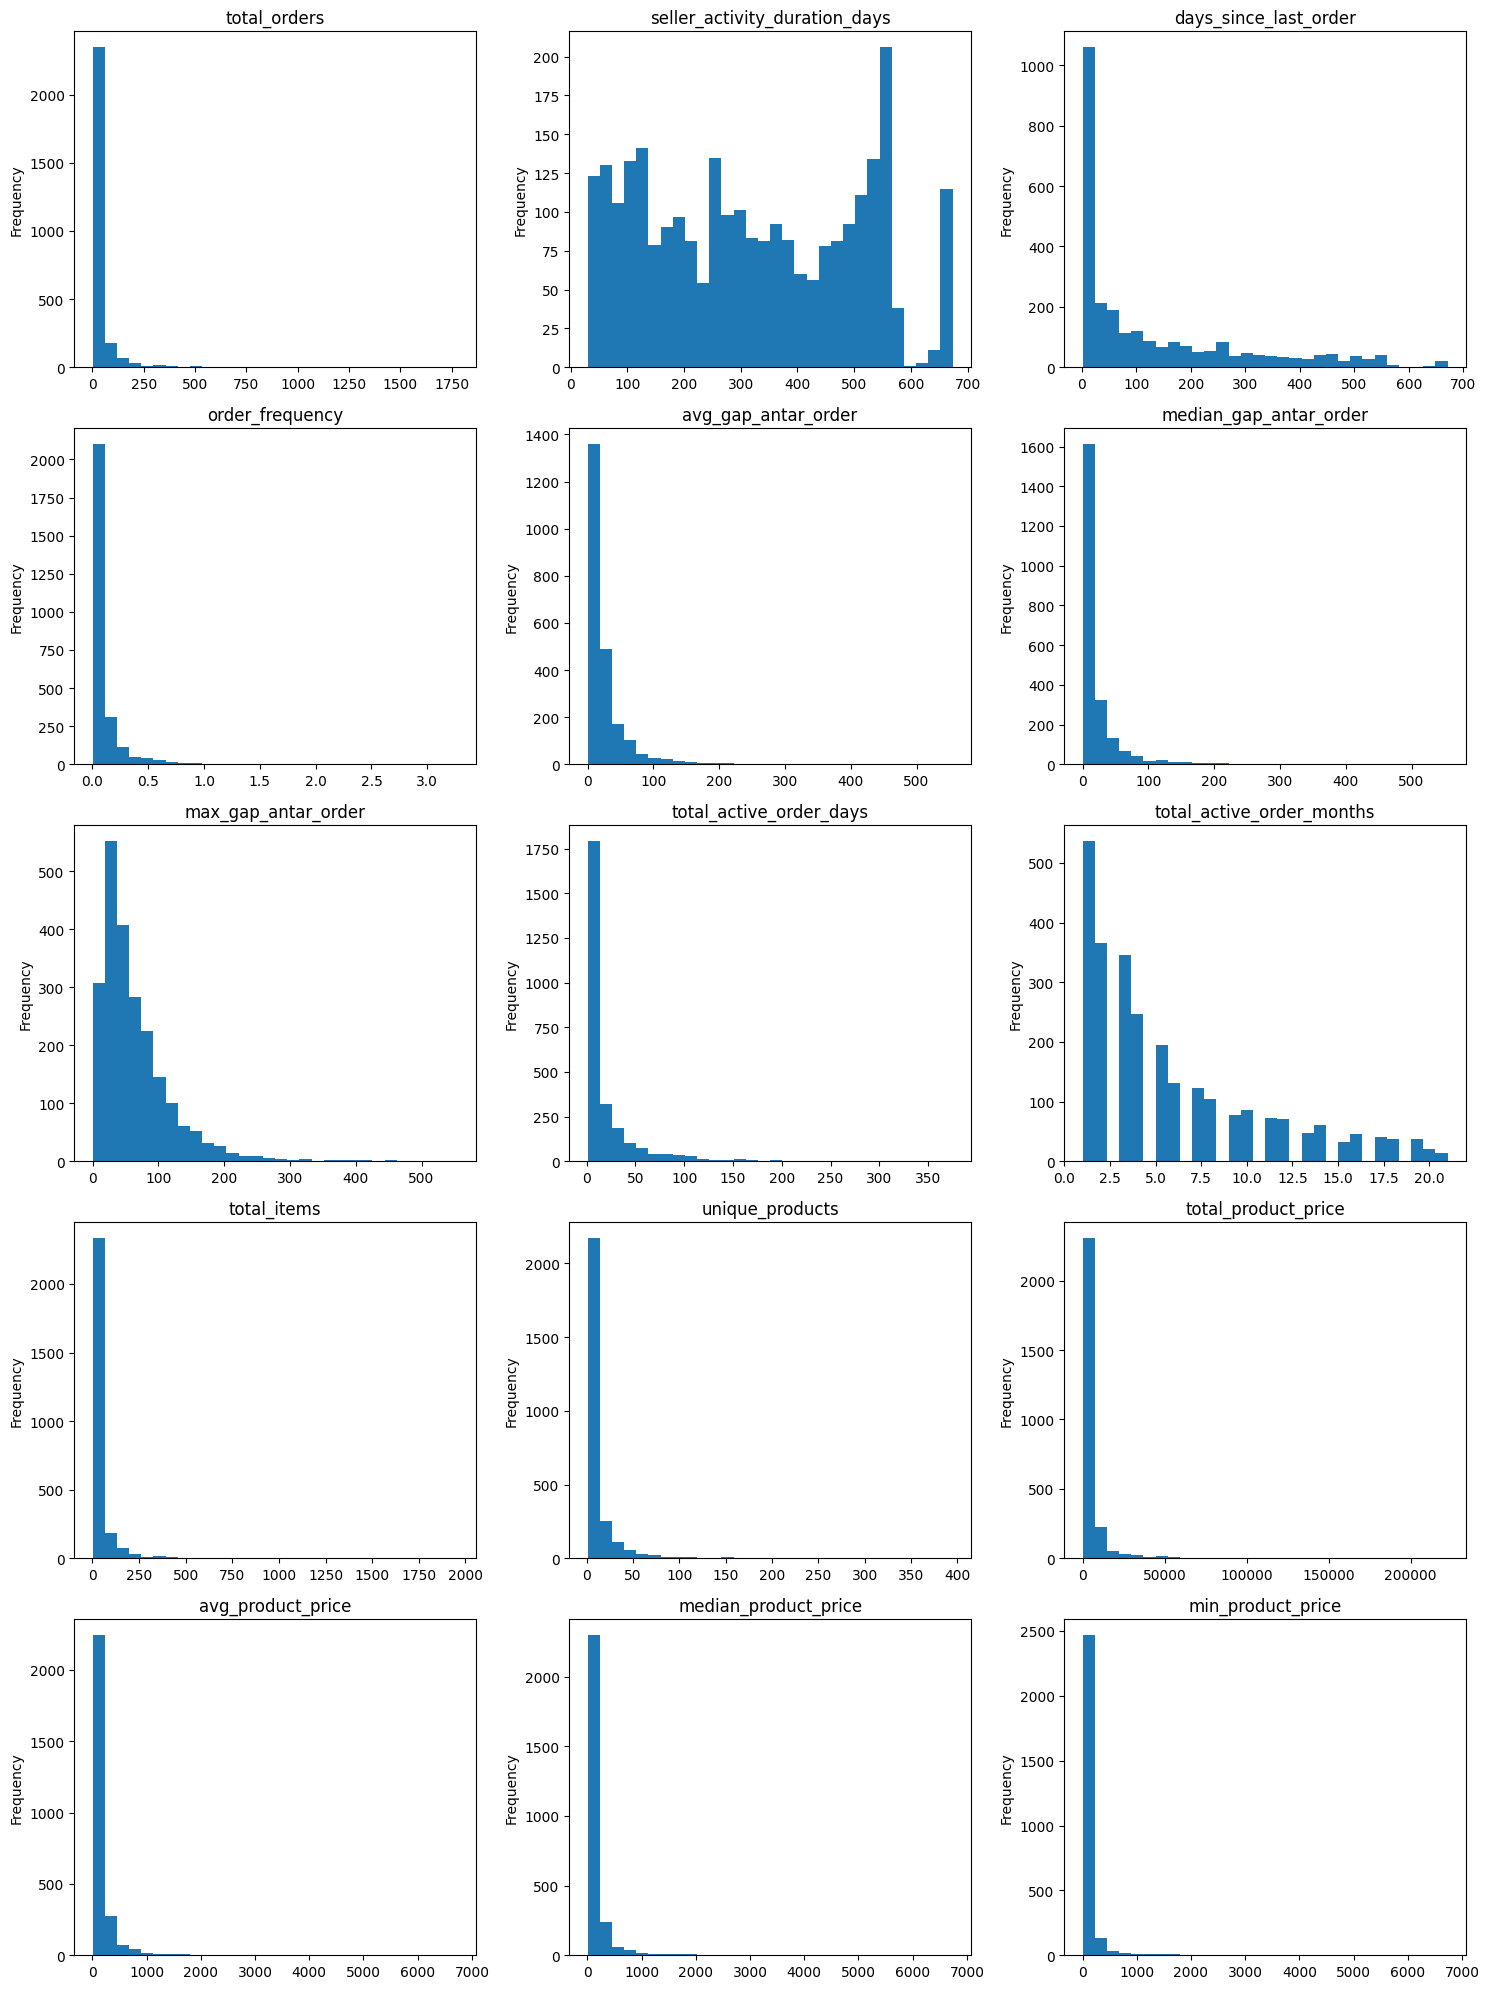

In [92]:
numeric_data = df_model.select_dtypes(include=['int64', 'float64'])

fig, axes = plt.subplots(5, 3, figsize=(15, 20))
axes = axes.flatten()

for ax, col in zip(axes, numeric_data.columns):
    ax.hist(df_model[col].dropna(), bins=30)
    ax.set_title(col)
    ax.set_xlabel('')
    ax.set_ylabel('Frequency')

for ax in axes[len(numeric_data.columns):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

Berdasarkan hasil distribusi, terlihat bahwa mayoritas distirbusi tidak normal (right skewed), sehingga proses imputasi dapat dilakukan dengan median.

In [93]:
df_model['churn_status'] = (
    df_model['churn_status']
    .map({
        'no churn': 0,
        'churn': 1
    })
)

In [94]:
df_model

,seller_id,churn_status,first_order,last_order,total_orders,seller_activity_duration_days,days_since_last_order,order_frequency,avg_gap_antar_order,median_gap_antar_order,max_gap_antar_order,total_active_order_days,total_active_order_months,total_items,unique_products,total_product_price,avg_product_price,median_product_price,min_product_price,max_product_price,total_freight_value,avg_freight_value,median_freight_value,total_payment_value,avg_payment_value,median_payment_value,max_payment_value,total_payment_records,avg_payment_installments,max_payment_installments,avg_unique_payment_types,avg_product_name_length,avg_product_description_length,avg_product_photos_qty,avg_product_weight_g,avg_product_length_cm,avg_product_height_cm,avg_product_width_cm,unique_product_categories,avg_product_volume_cm3,min_seller_customer_distance_km,avg_seller_customer_distance_km,median_seller_customer_distance_km,max_seller_customer_distance_km
0,0015a82c2db000af6aaaf3ae2ecb0532,1,2017-09-29 15:53:03,2017-10-20 14:29:01,3,317.163484,296.221840,0.009459,10.470822,10.470822,17.992812,3,2,3,1,2685.00,895.000000,895.00,895.00,895.00,63.06,21.020000,21.020,2748.06,916.020000,916.020,916.02,3,7.333333,10,1.000000,40.000000,849.000000,2.000000,11800.000000,40.000000,43.000000,36.000000,1,61920.000000,417.373963,606.563346,687.896184,714.419890
1,001cca7ae9ae17fb1caed9dfb1094831,1,2017-02-10 09:24:35,2018-07-13 13:32:00,200,548.433252,30.261435,0.364675,2.603878,1.059618,42.975694,126,17,239,11,25080.03,104.937364,99.00,69.90,199.00,8854.14,37.046611,36.850,34020.14,170.100700,144.990,735.96,202,3.6375,10,1.005000,37.272727,485.454545,2.090909,8772.727273,42.000000,13.272727,38.545455,2,21392.272727,15.215576,809.368650,736.794692,2531.005836
2,002100f778ceb8431b7a1020ff7ab48f,1,2017-09-15 19:26:09,2018-04-12 23:11:48,51,331.015498,121.858796,0.154071,4.183134,2.539369,28.180417,39,8,55,24,1234.50,22.445455,17.90,9.90,129.90,793.66,14.430182,15.100,2202.64,43.189020,33.000,182.92,54,1.460784,5,1.058824,54.125000,664.000000,1.000000,372.916667,16.166667,26.500000,19.000000,1,8324.000000,85.122545,529.287951,362.441972,2124.553351
3,003554e2dce176b5555353e4f3555ac8,1,2017-12-15 19:45:04,2017-12-15 19:45:04,1,240.002361,240.002361,0.004167,NaN,NaN,NaN,1,1,1,1,120.00,120.000000,120.00,120.00,120.00,19.38,19.380000,19.380,139.38,139.380000,139.380,139.38,1,3.0,3,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,NaN,936.523276,936.523276,936.523276,936.523276
4,004c9cd9d87a3c30c522c48c4fc07416,1,2017-01-30 10:18:21,2018-05-07 16:31:00,158,559.395914,97.137130,0.282448,2.944323,1.864815,19.239248,111,17,170,88,19712.71,115.957118,109.99,47.90,259.99,3551.23,20.889588,17.830,23367.54,147.895823,130.440,652.34,188,4.367089,11,1.012658,57.000000,598.518987,1.050633,2422.177215,37.443038,11.265823,34.873418,1,15875.240506,43.284401,644.610694,549.078342,2292.303810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2687,ffc470761de7d0232558ba5e786e57b7,0,2018-02-21 21:06:33,2018-08-03 12:57:00,26,171.945775,9.285741,0.151210,6.506401,5.357650,28.054664,23,7,29,14,1569.11,54.107241,30.05,24.90,245.90,403.55,13.915517,14.100,1972.66,75.871538,55.870,262.38,28,1.557692,5,1.076923,55.142857,793.214286,1.500000,1054.571429,23.500000,17.857143,22.071429,7,11533.714286,9.462623,522.791513,324.217516,2356.890930
2688,ffdd9f82b9a447f6f8d4b91554cc7dd3,0,2017-03-06 14:01:10,2018-07-31 15:50:00,17,524.241181,12.165602,0.032428,32.004724,31.884398,79.856991,15,11,19,11,2001.60,105.347368,99.00,13.00,214.00,715.27,37.645789,17.130,2716.87,159.815882,115.940,625.74,18,3.823529,10,1.058824,48.363636,533.909091,1.272727,4442.454545,31.909091,22.545455,25.545455,2,28267.454545,3.283441,485.639180,338.399959,1160.528977
2689,ffeee66ac5d5a62fe688b9d26f83f534,1,2017-10-02 20:42:08,2018-06-13 13:56:00,14,313.962731,60.244769,0.044591,19.516766,12.020949,103.565208,12,7

### **d) Analisis Multivariat Numerik vs Target**

total_orders


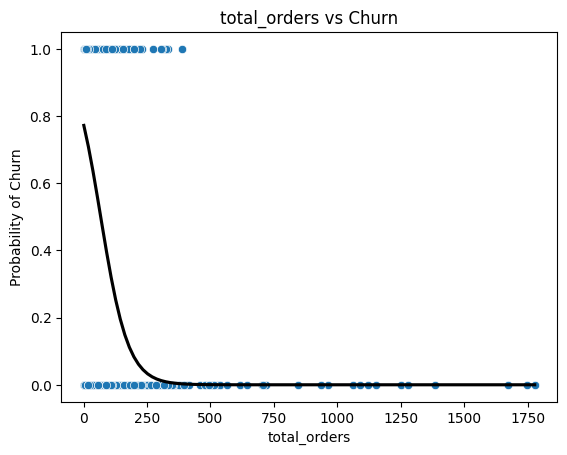

seller_activity_duration_days


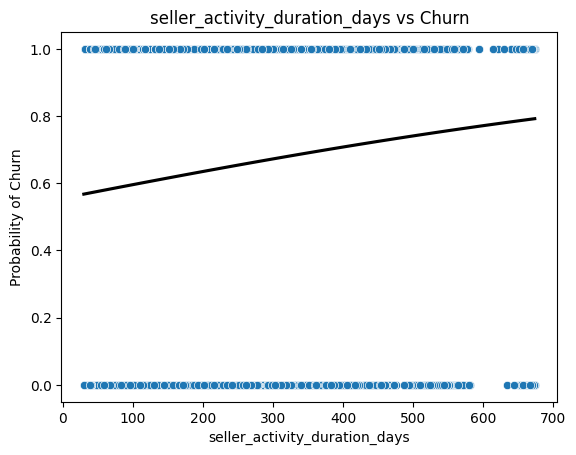

days_since_last_order


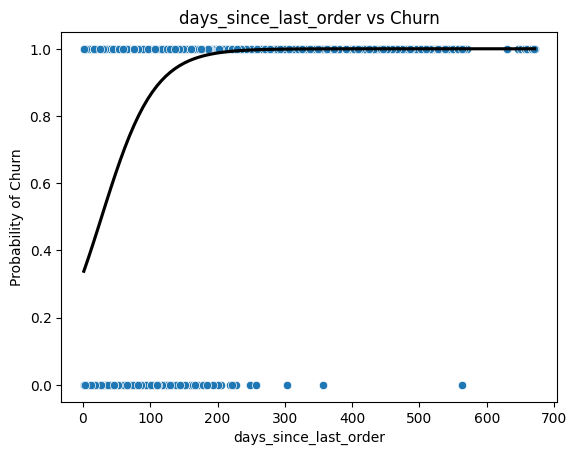

order_frequency


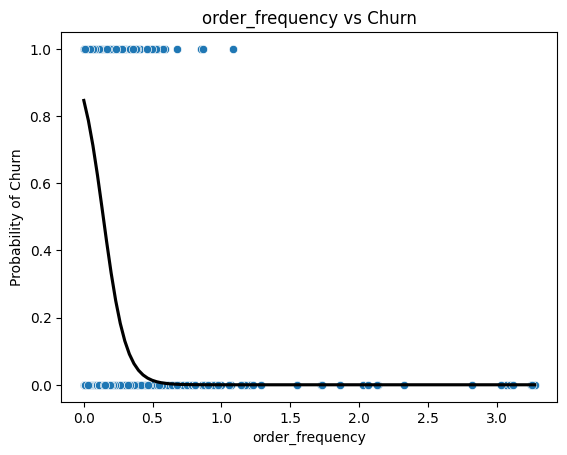

avg_gap_antar_order


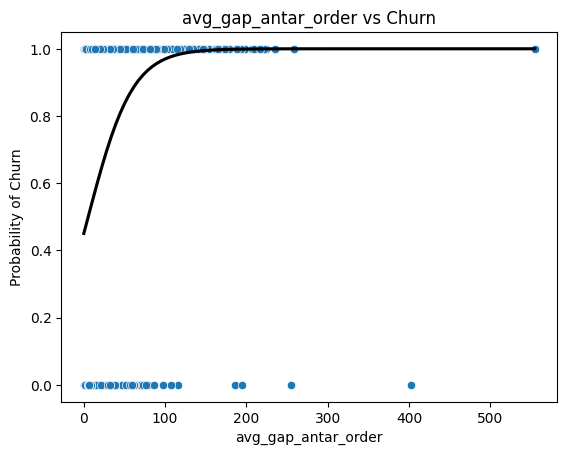

median_gap_antar_order


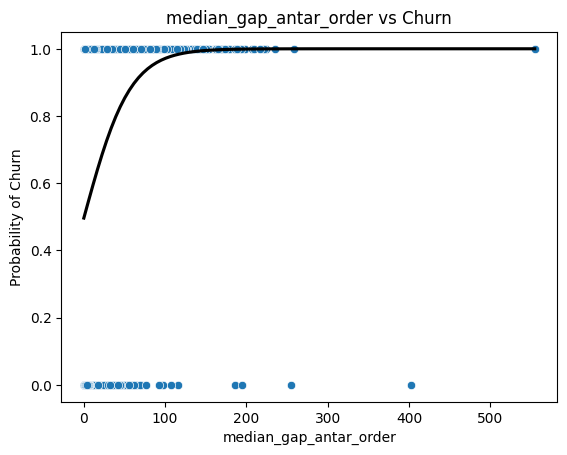

max_gap_antar_order


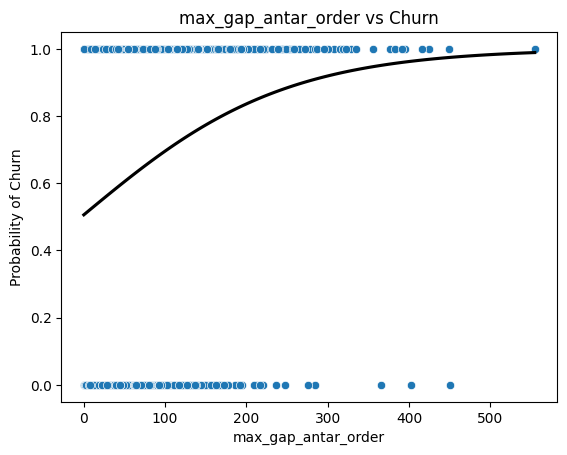

total_active_order_days


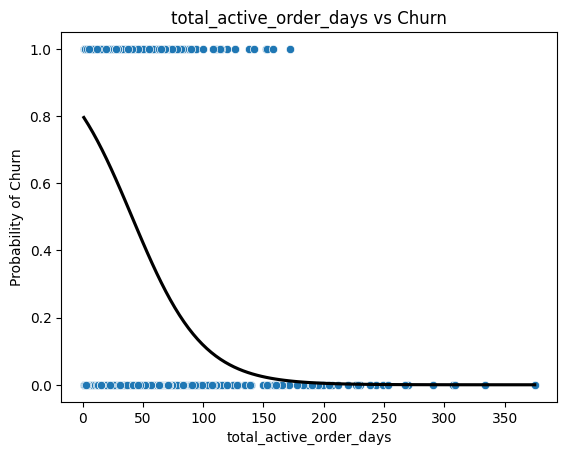

total_active_order_months


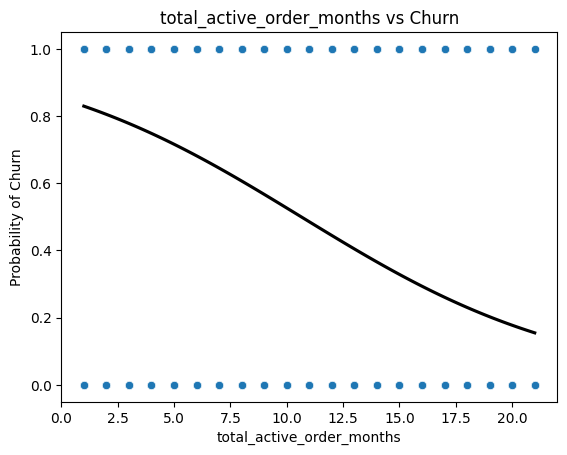

total_items


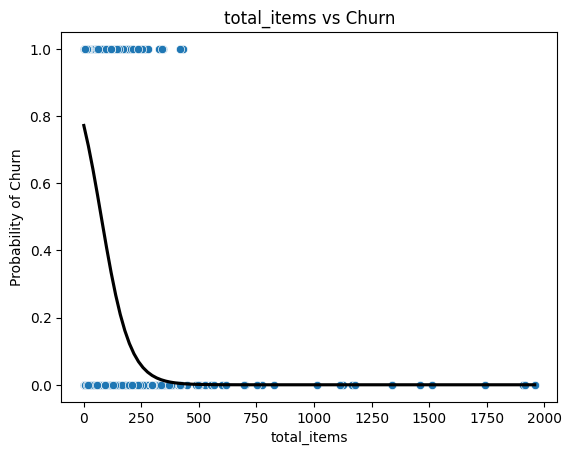

unique_products


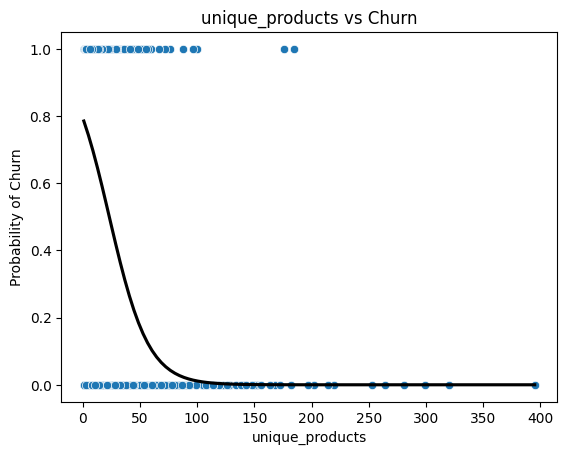

total_product_price


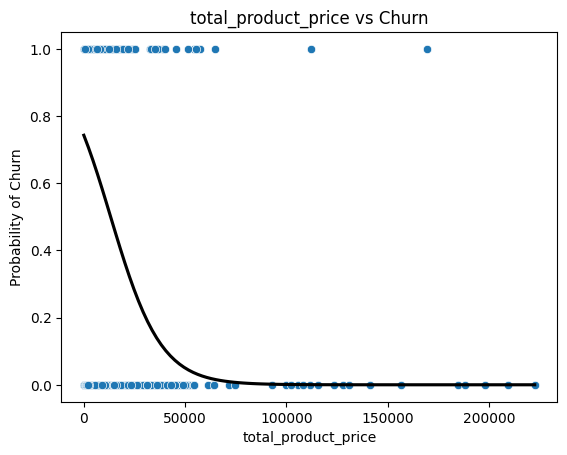

avg_product_price


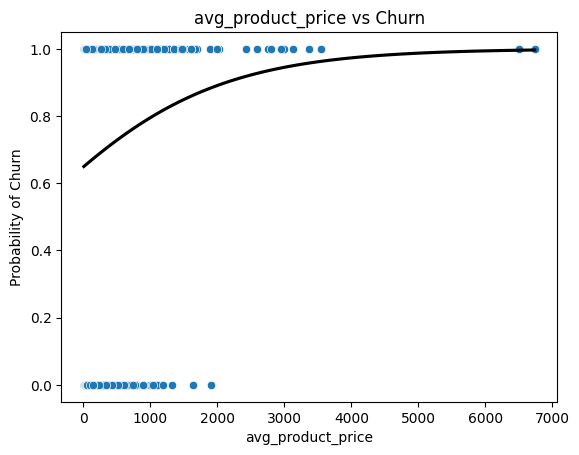

median_product_price


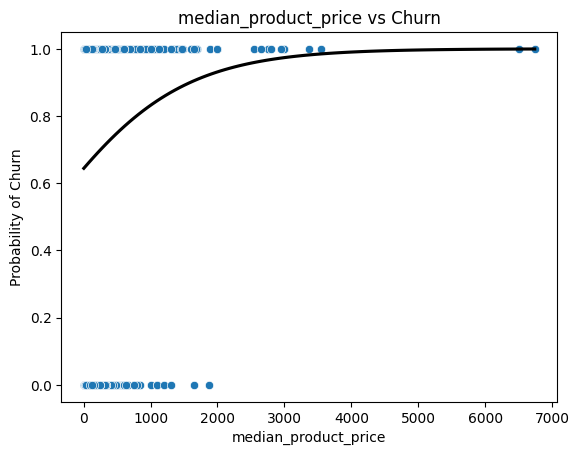

min_product_price


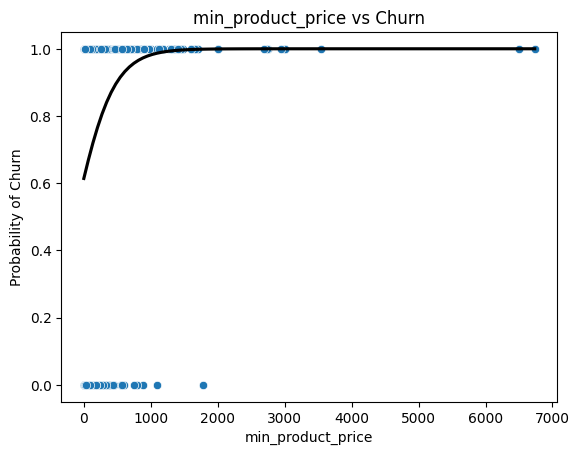

max_product_price


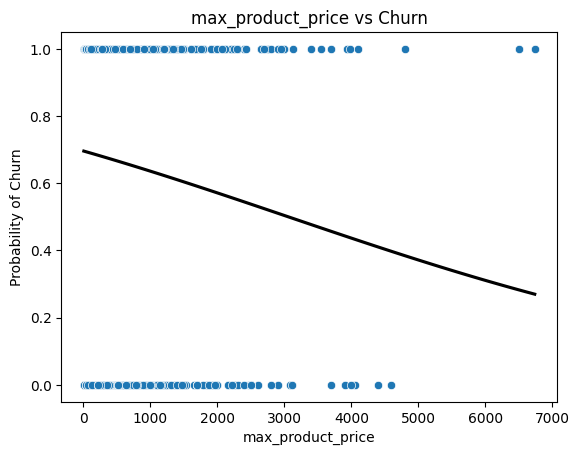

total_freight_value


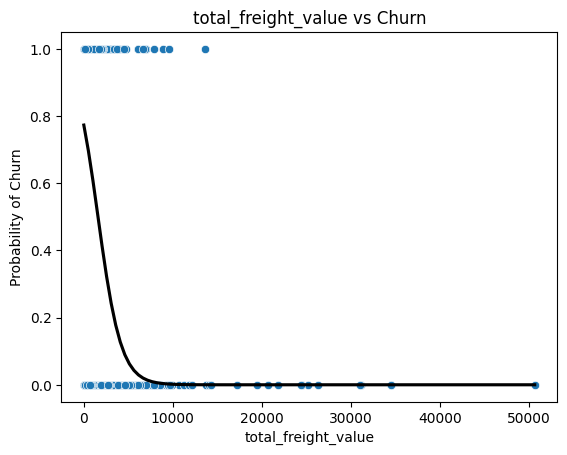

avg_freight_value


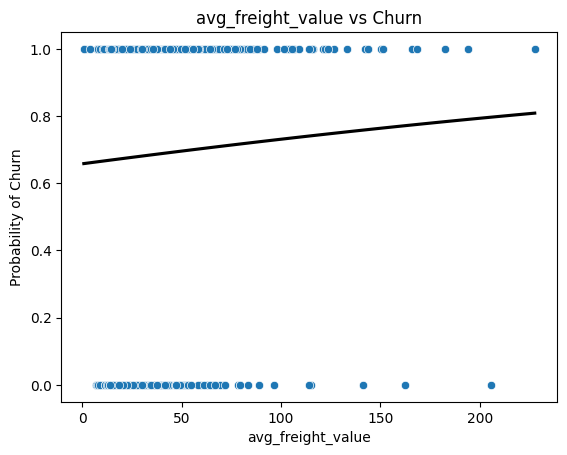

median_freight_value


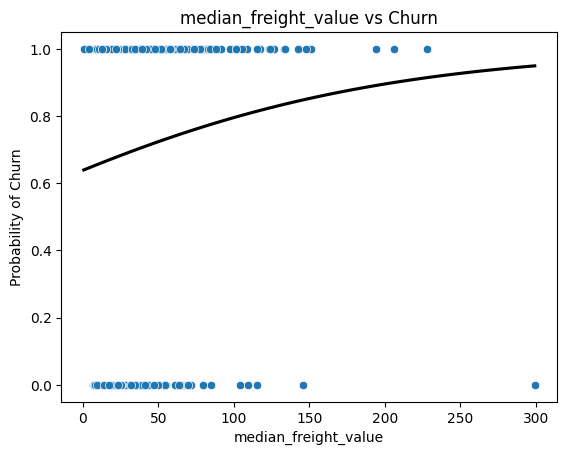

total_payment_value


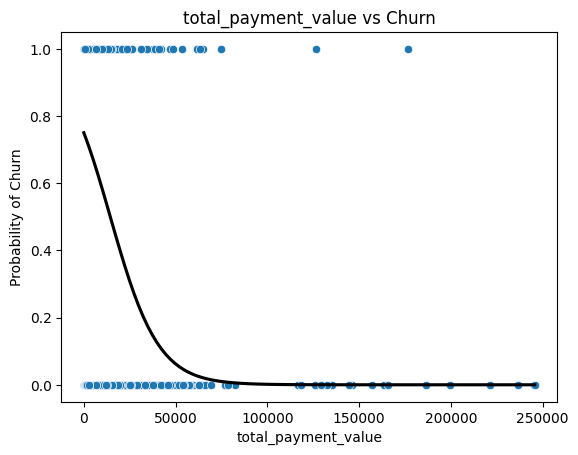

avg_payment_value


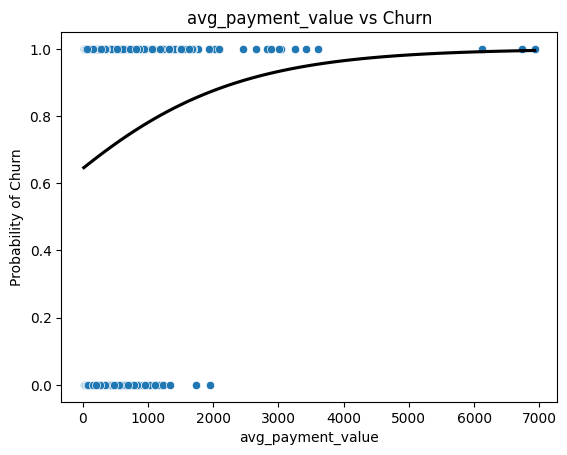

median_payment_value


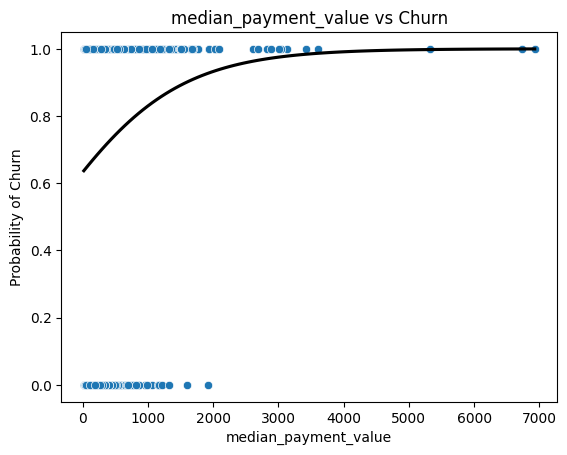

max_payment_value


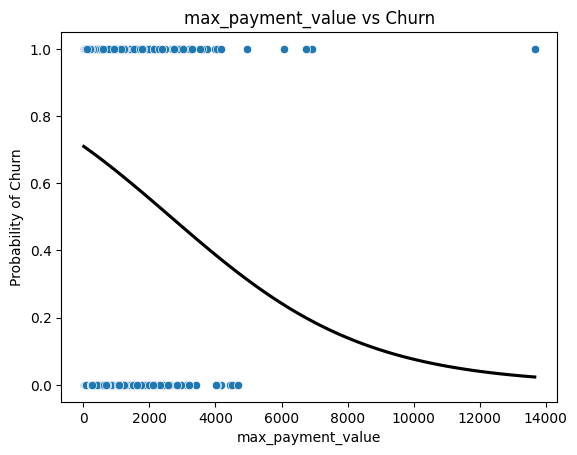

total_payment_records


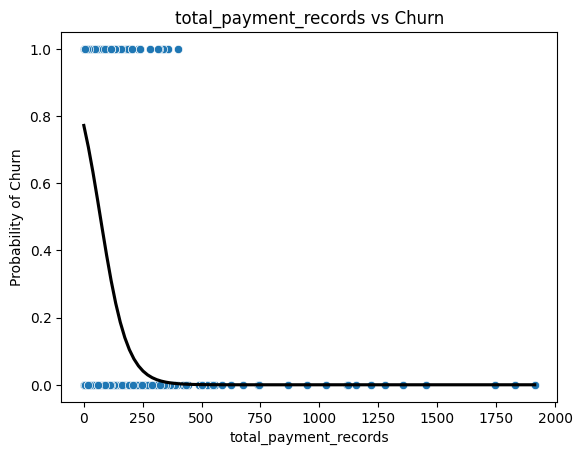

avg_payment_installments


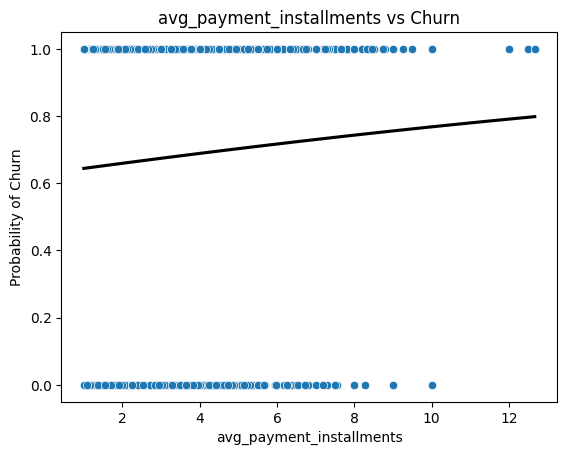

max_payment_installments


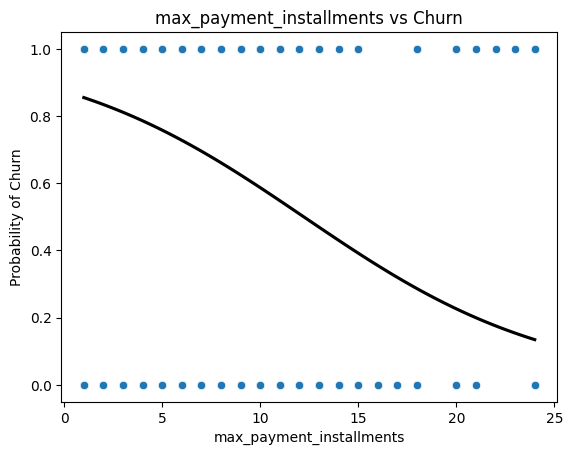

avg_unique_payment_types


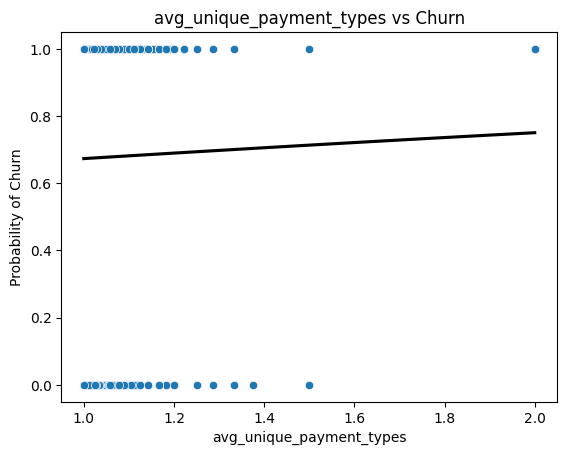

avg_product_name_length


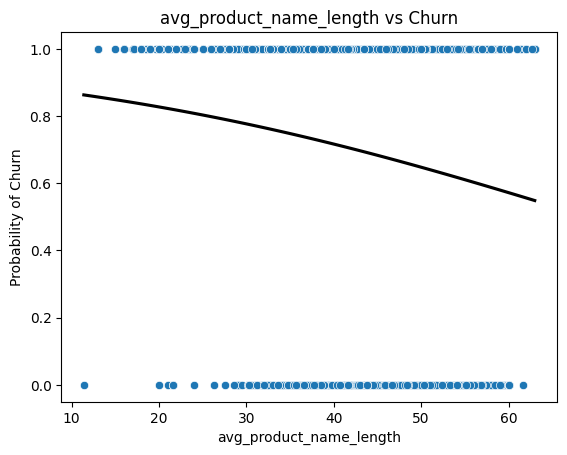

avg_product_description_length


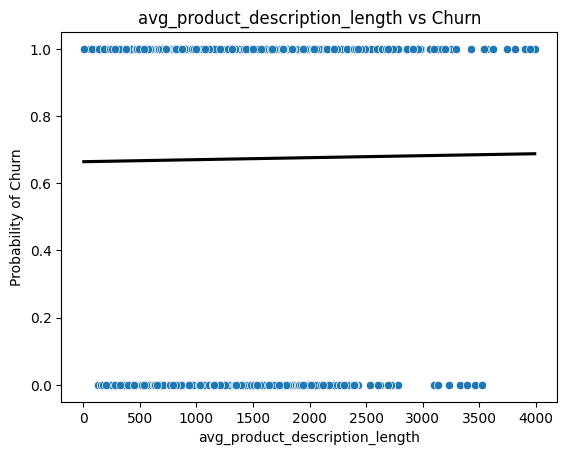

avg_product_photos_qty


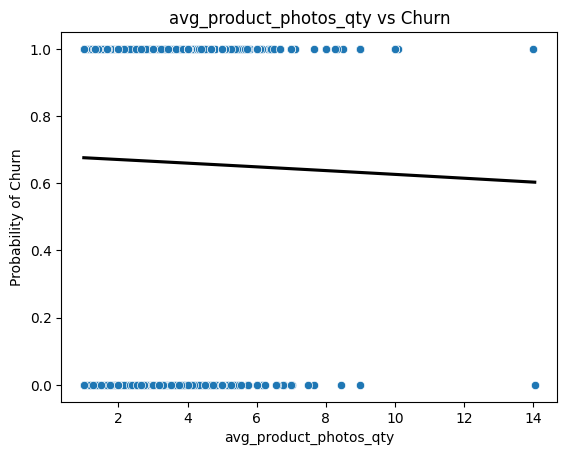

avg_product_weight_g


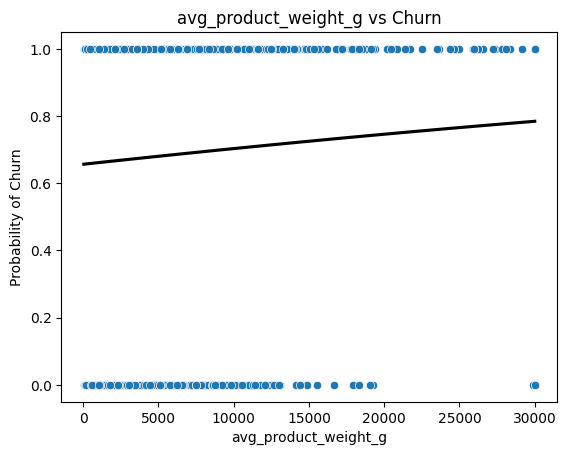

avg_product_length_cm


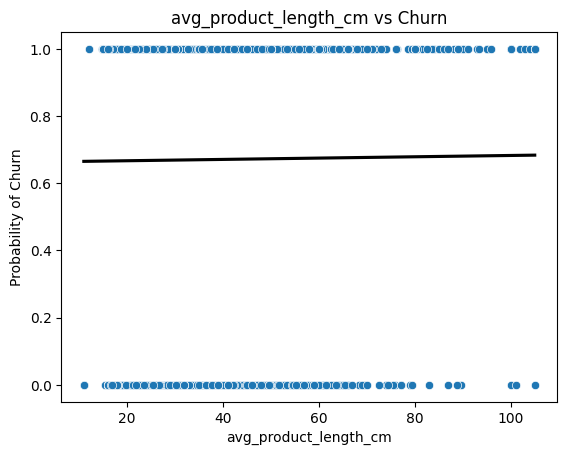

avg_product_height_cm


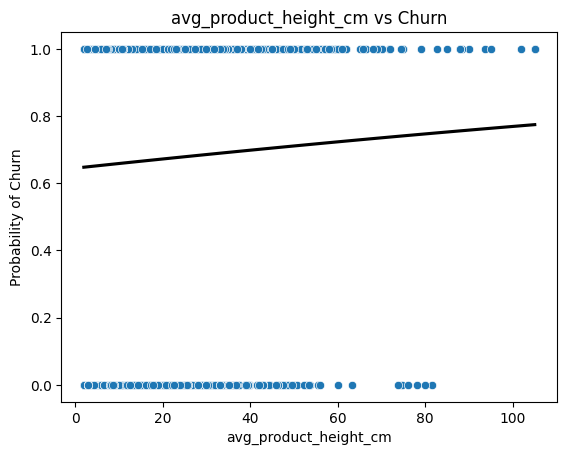

avg_product_width_cm


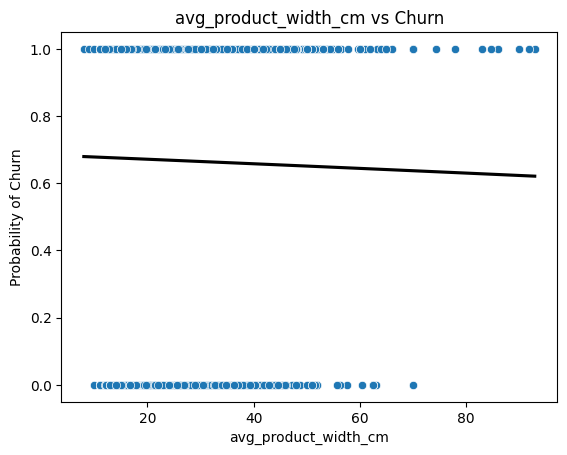

unique_product_categories


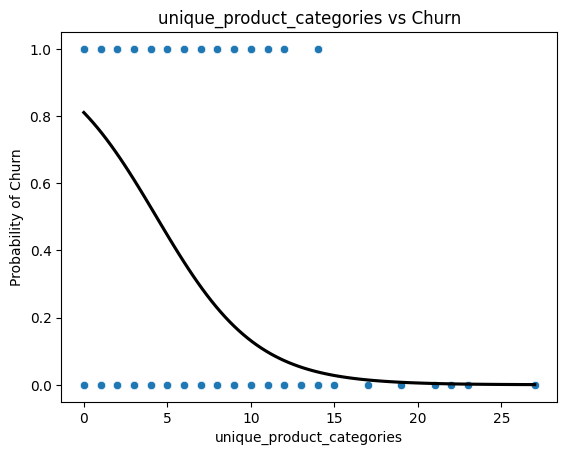

avg_product_volume_cm3


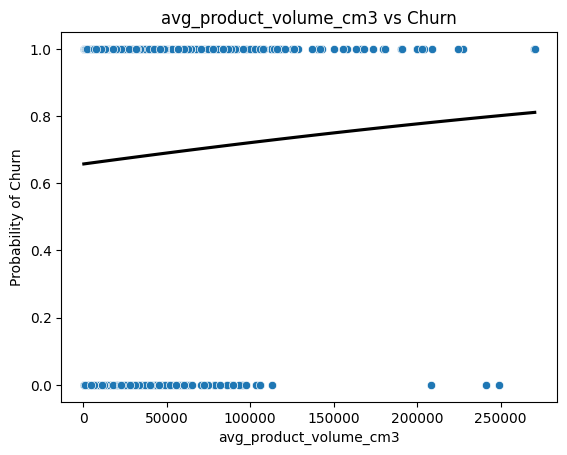

min_seller_customer_distance_km


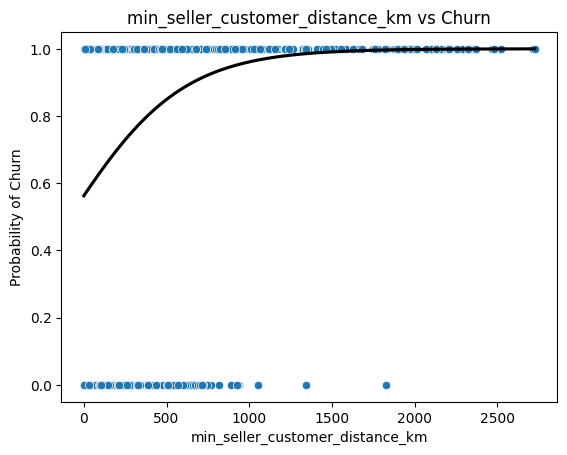

avg_seller_customer_distance_km


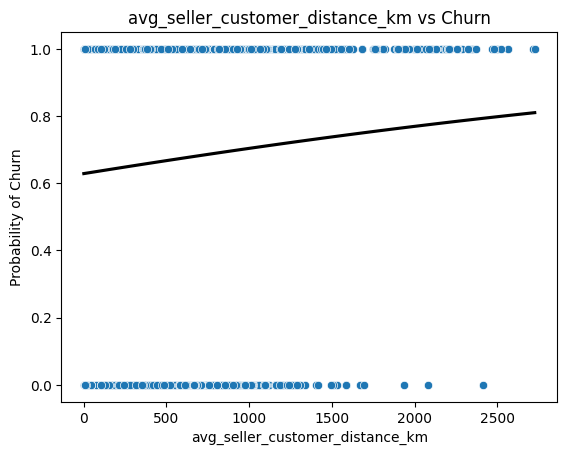

median_seller_customer_distance_km


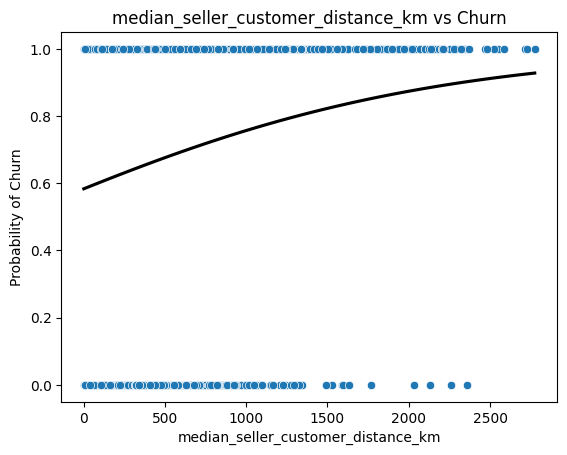

max_seller_customer_distance_km


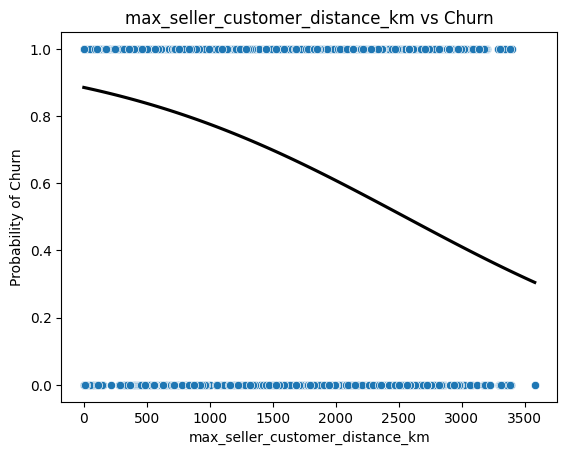

In [95]:
for i in df_model.select_dtypes(include=['int64','float64']):
    if i not in ['churn_status']:
      print(i)
      sns.scatterplot(x = i, y='churn_status', data=df_model)
      sns.regplot(x=i, y='churn_status', data=df_model, scatter=False, color='black', ci=None, logistic=True)
      plt.title(f'{i} vs Churn')
      plt.xlabel(i)
      plt.ylabel('Probability of Churn')
      plt.show()
      print("="*90)

Multivariat ini digunakan untuk dasar penentuan fitur yang relevan dengan kontes bisnis.

### **e) Boxplot Numerical vs Target**

total_orders
-0.2724378958286425


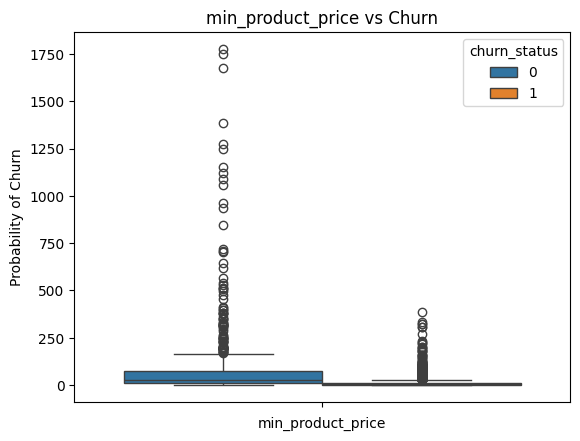

seller_activity_duration_days
0.1391209828521482


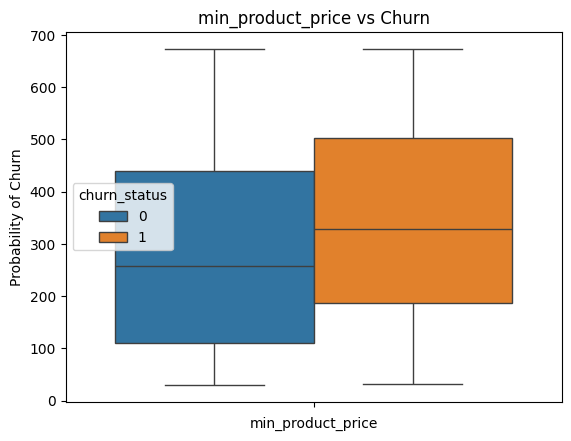

days_since_last_order
0.4768142346267602


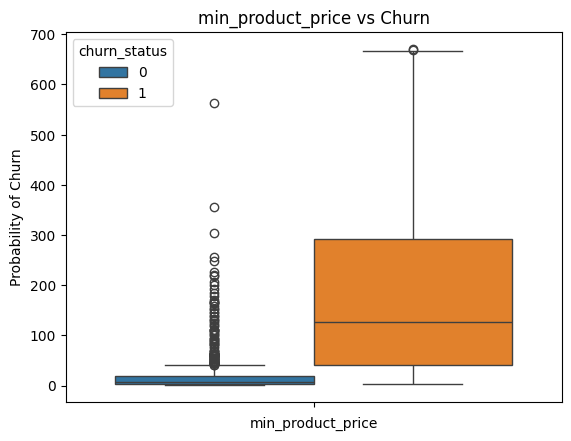

order_frequency
-0.35397655967956176


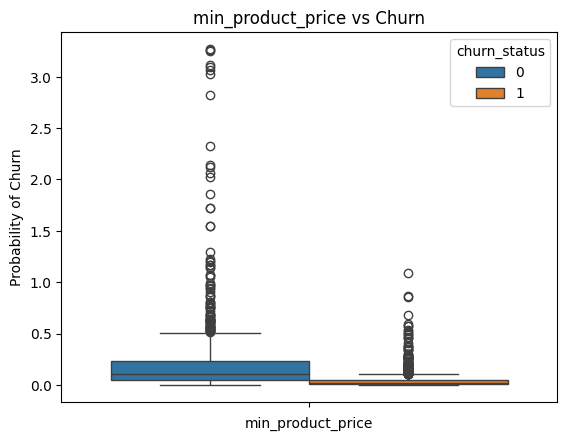

avg_gap_antar_order
0.2529383358092767


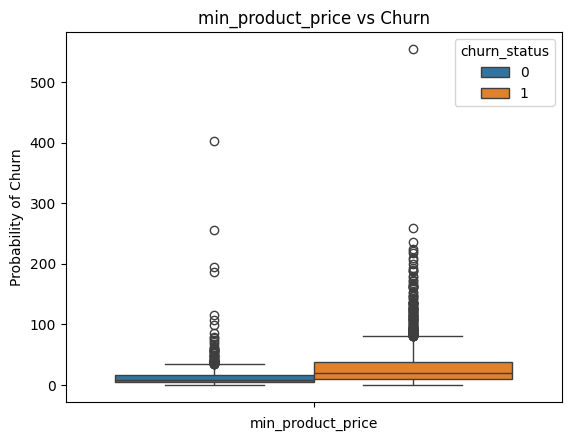

median_gap_antar_order
0.23147041977512298


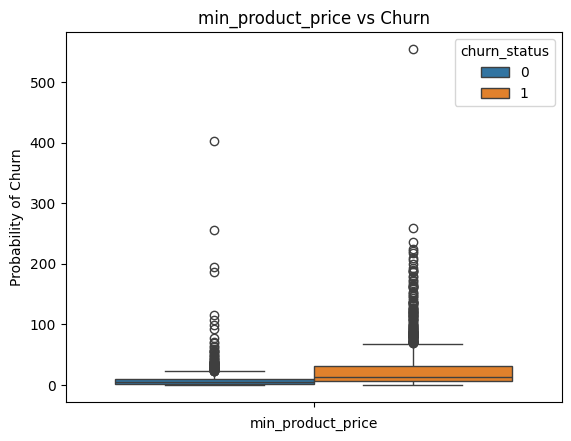

max_gap_antar_order
0.17530203410861972


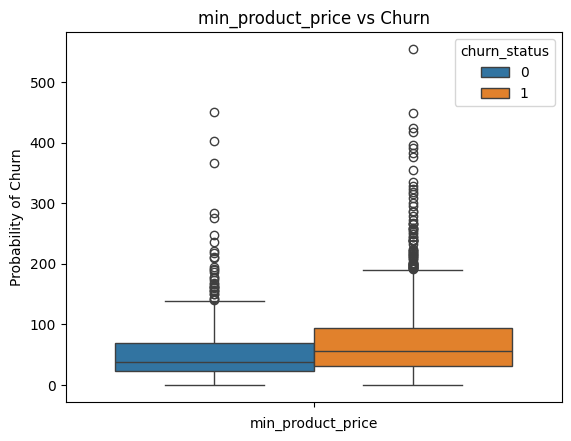

total_active_order_days
-0.38078109569345714


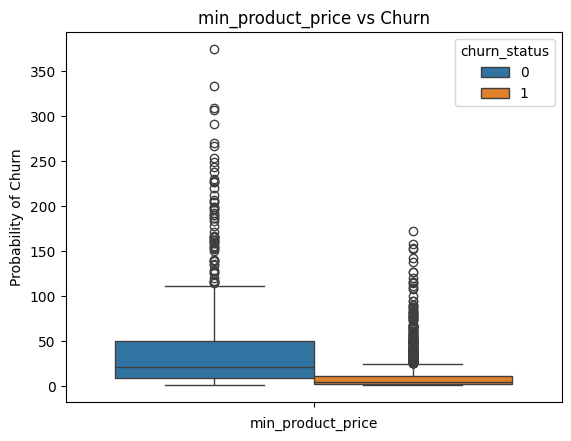

total_active_order_months
-0.3805658542111777


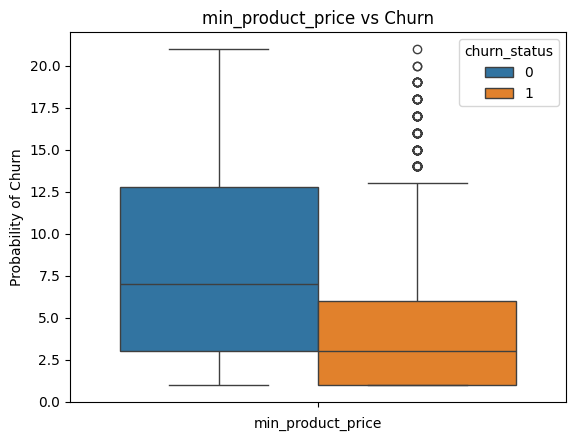

total_items
-0.2687259714261906


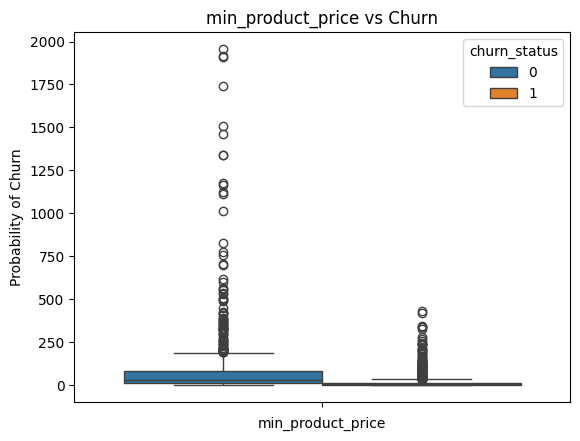

unique_products
-0.32122002804858285


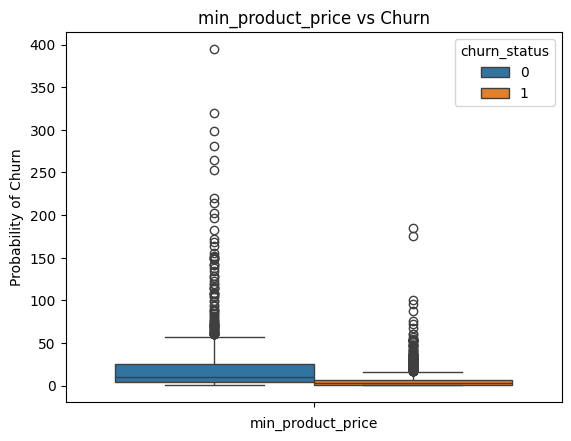

total_product_price
-0.23585435278733927


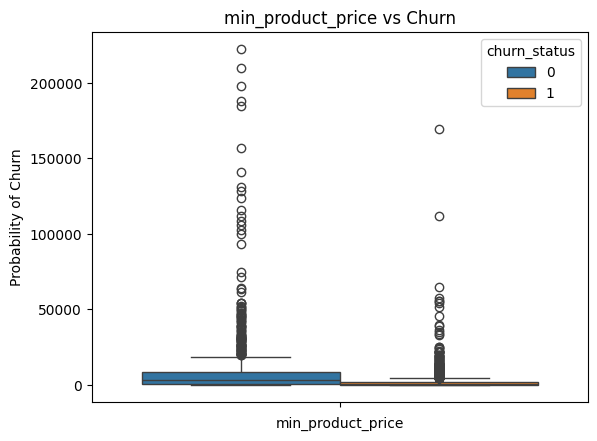

avg_product_price
0.0709536042508305


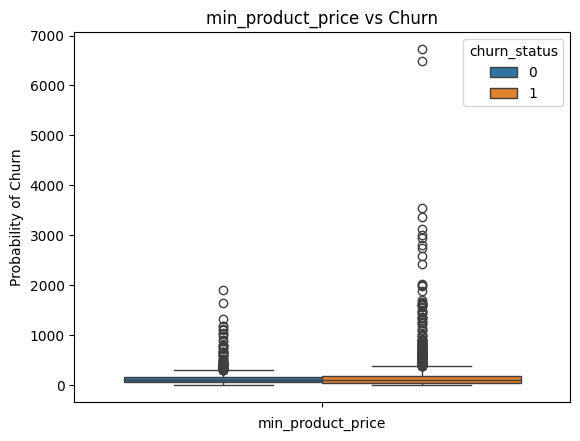

median_product_price
0.08320755880794478


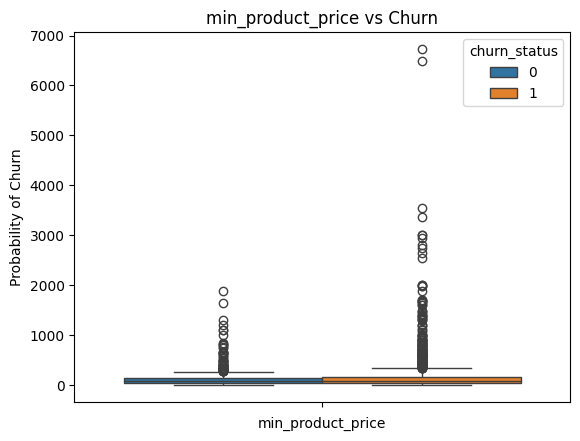

min_product_price
0.11226880590812578


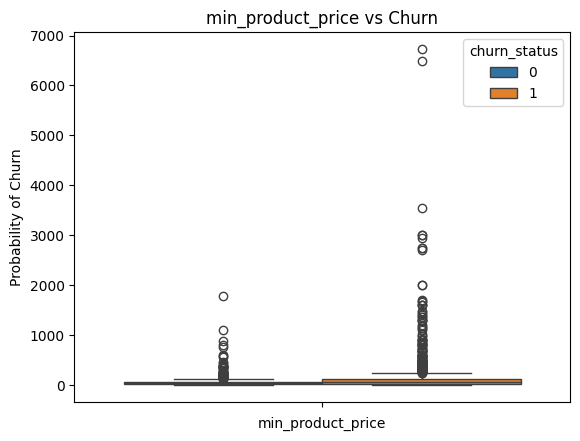

max_product_price
-0.07095709479165378


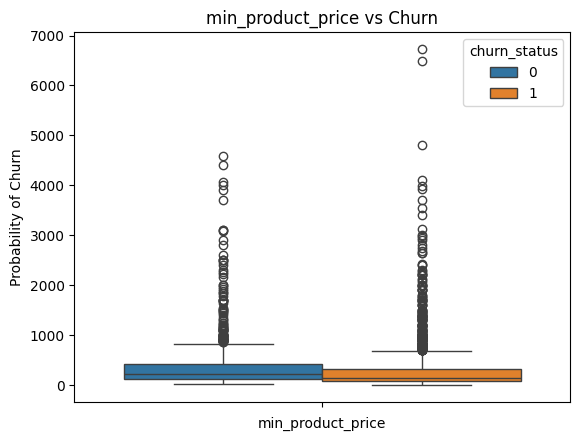

total_freight_value
-0.26186710044601


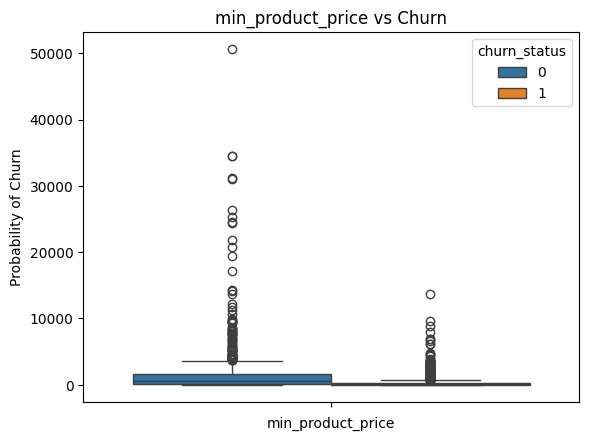

avg_freight_value
0.02683132035607777


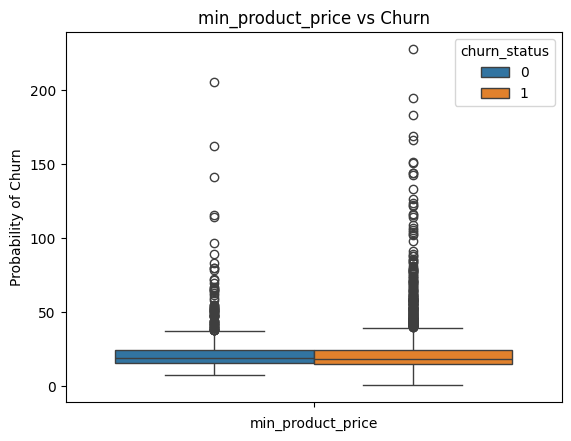

median_freight_value
0.053711407919212896


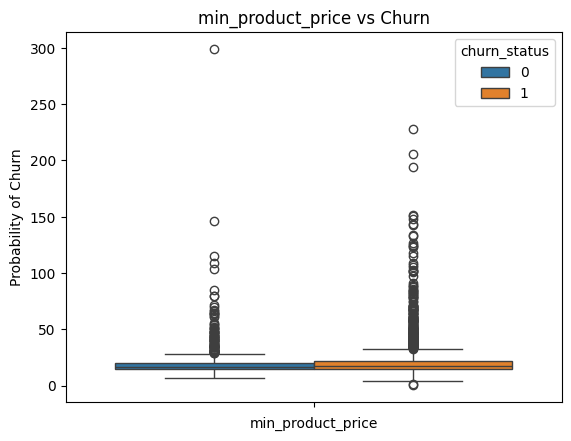

total_payment_value
-0.24670015305377252


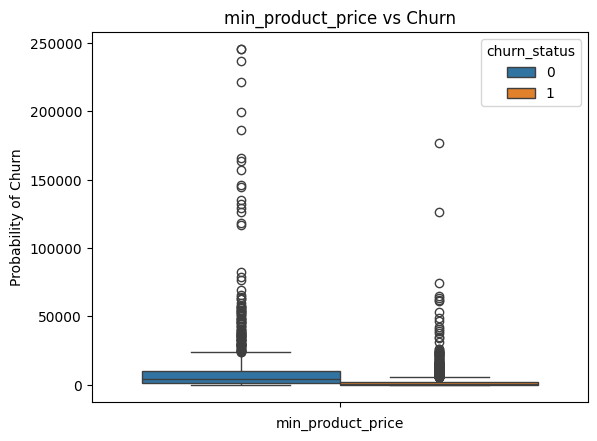

avg_payment_value
0.07244425453725348


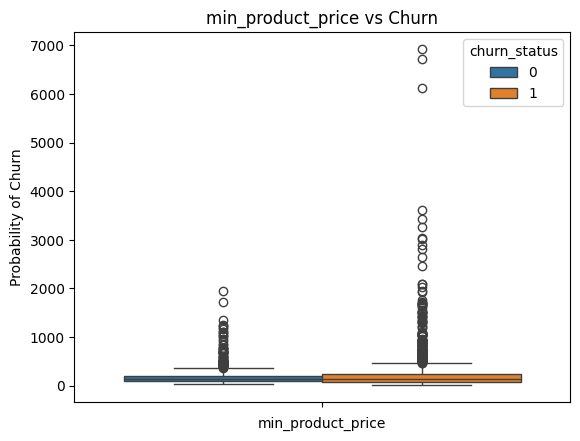

median_payment_value
0.09107670149788216


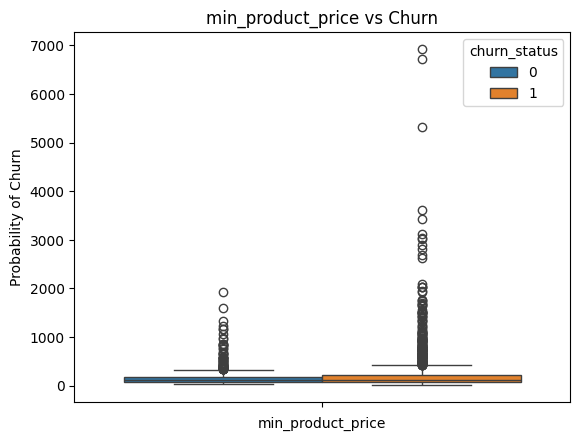

max_payment_value
-0.10377854367697248


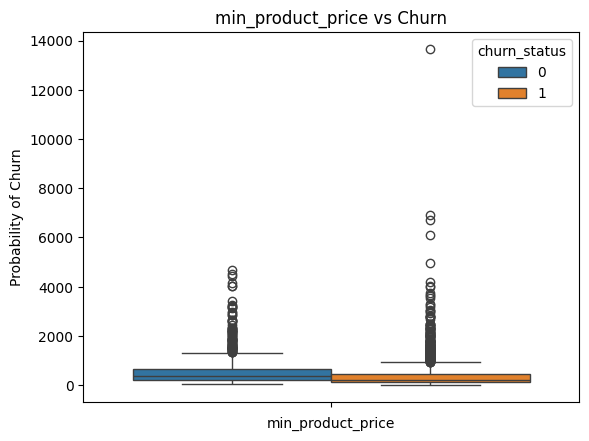

total_payment_records
-0.27142328410539707


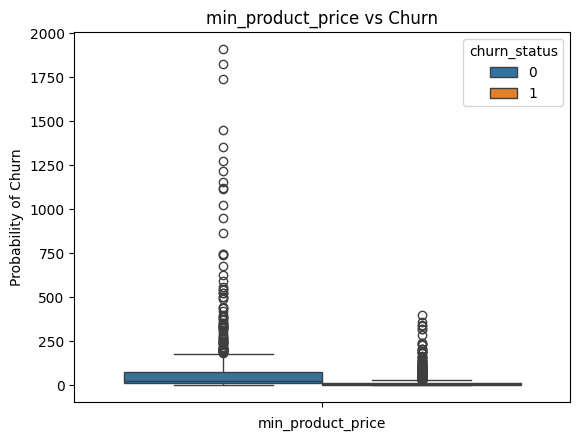

avg_payment_installments
0.055953219853127074


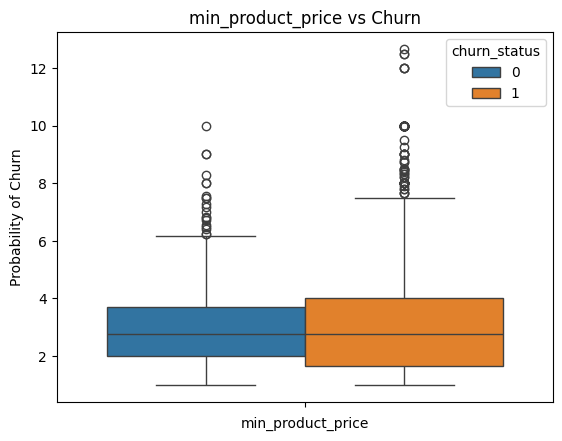

max_payment_installments
-0.2837902125890064


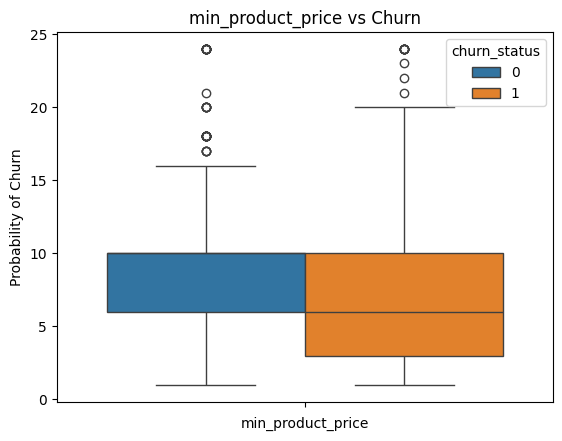

avg_unique_payment_types
0.015412534726950759


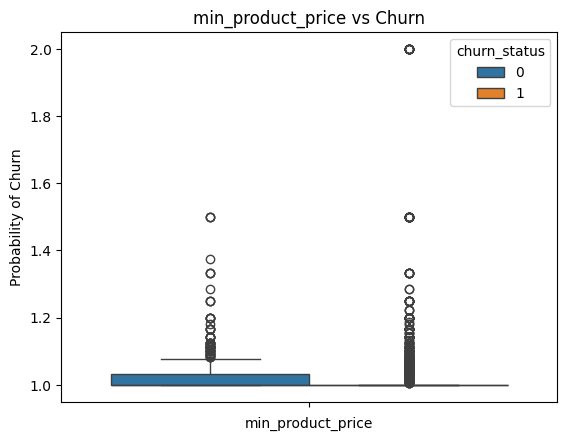

avg_product_name_length
-0.12765597759954064


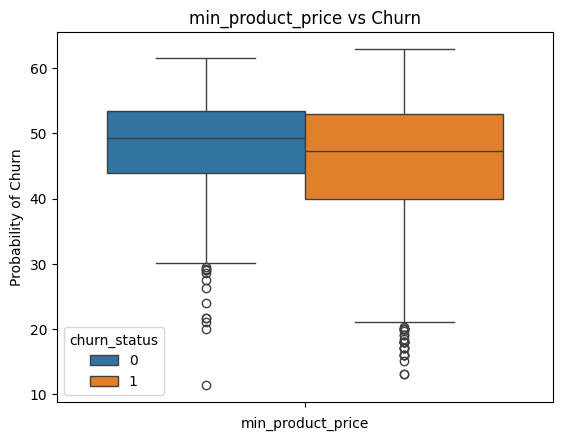

avg_product_description_length
0.007435119834224585


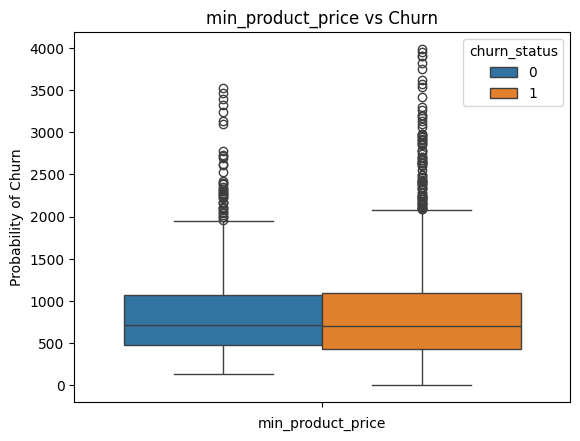

avg_product_photos_qty
-0.01667179146285121


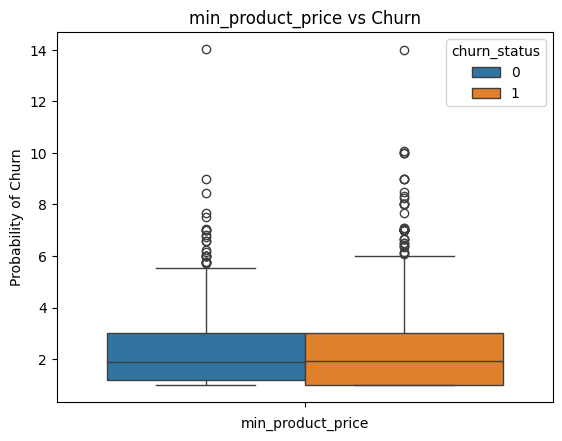

avg_product_weight_g
0.041501859140740026


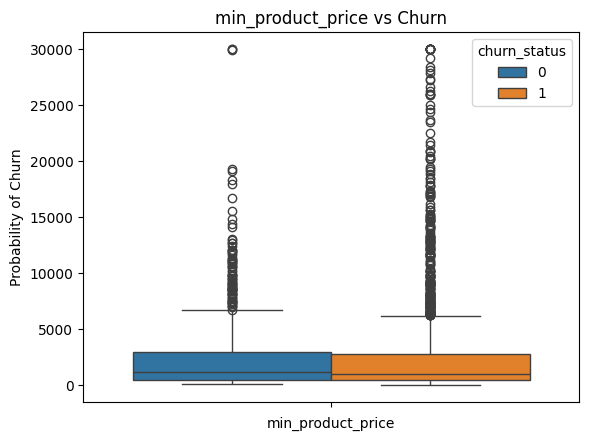

avg_product_length_cm
0.006586821980648885


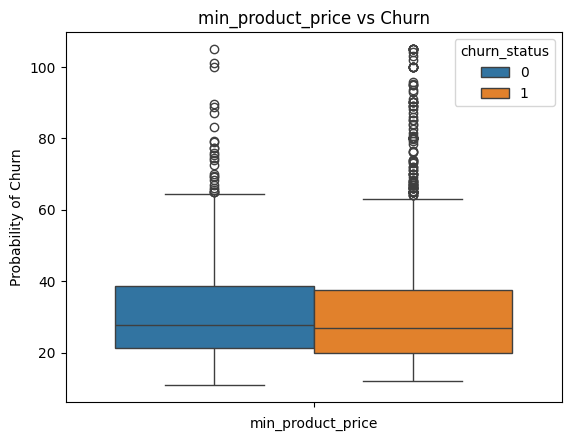

avg_product_height_cm
0.035027608955107495


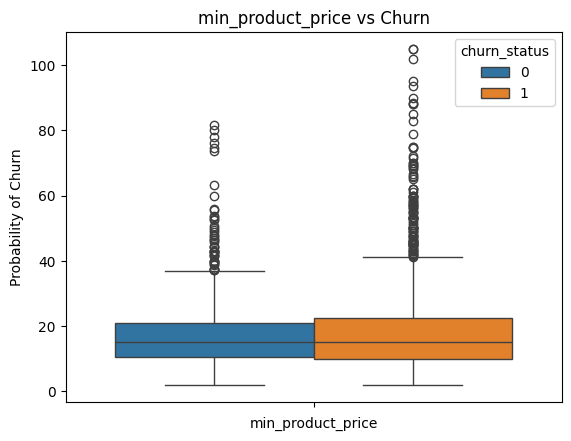

avg_product_width_cm
-0.015082962493567276


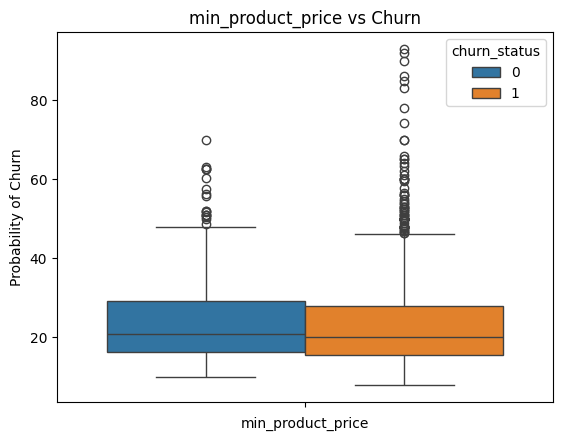

unique_product_categories
-0.2875078886561667


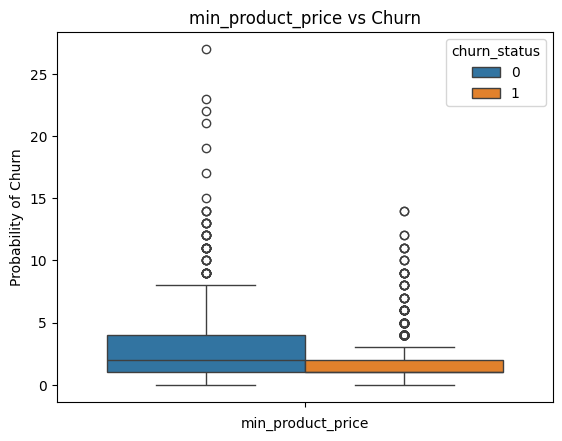

avg_product_volume_cm3
0.03532324909342233


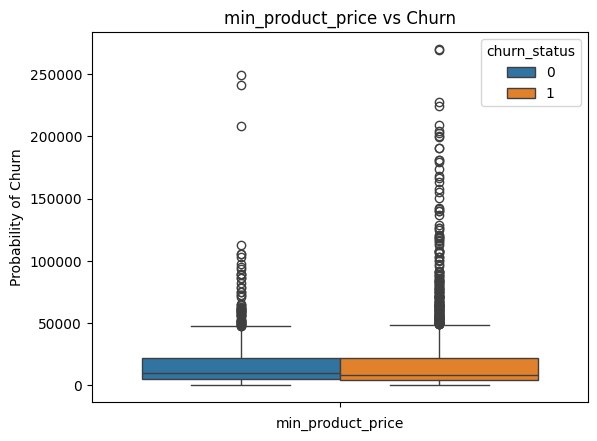

min_seller_customer_distance_km
0.24084537879315093


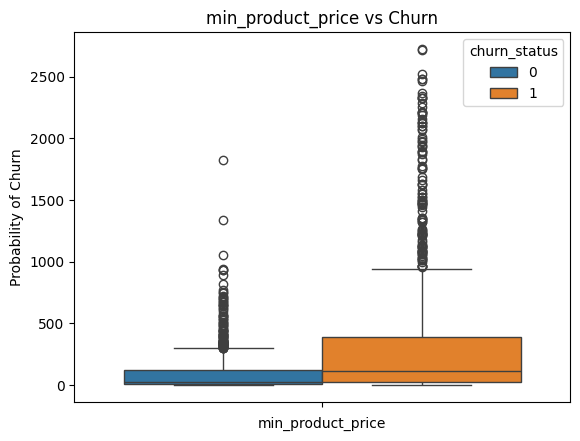

avg_seller_customer_distance_km
0.05707644903066724


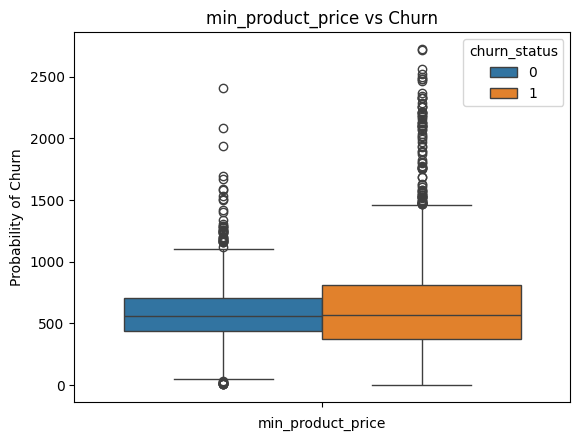

median_seller_customer_distance_km
0.12668642807864275


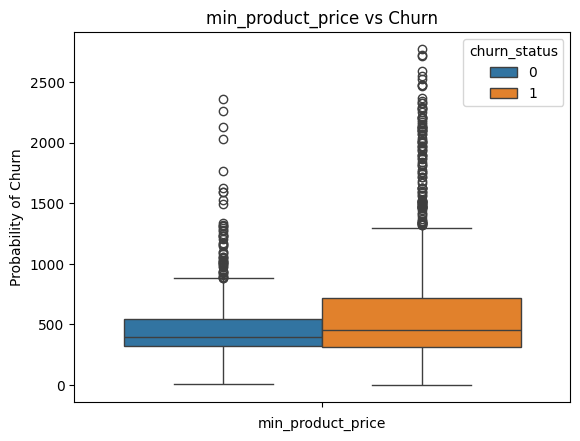

max_seller_customer_distance_km
-0.30723414749255845


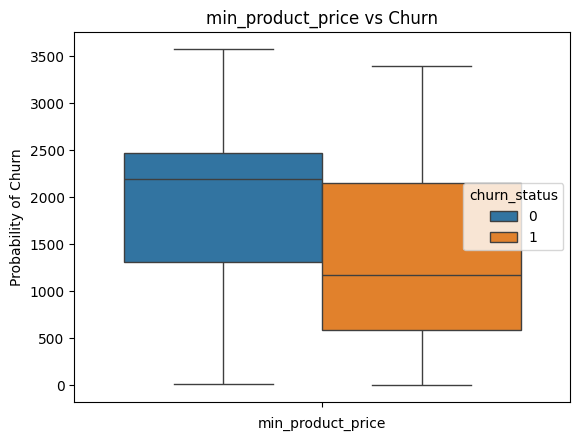

In [96]:
for i in df_model.select_dtypes(include=['int64','float64']):
    if i not in ['churn_status']:
      print(i)
      print(df_model[i].corr(df_model['churn_status']))
      sns.boxplot(hue='churn_status', y=i, data=df_model)
      plt.title(f'{col} vs Churn')
      plt.xlabel(col)
      plt.ylabel('Probability of Churn')
      plt.show()

Boxplot ini digunakan untuk menentukan fitur yang relevan, selain itu juga dapat melihat outlier dari setiap fitur.

### **f) Korelasi antar Fitur Numerik**

Seteleh melihat hasil analisis multivariat dan boxplot dilakukan korelasi antar fitur numerik untuk menentukan suatu fitur perlu dipertahankan atau tidak, sehingga hal ini menghindari multikolinearitas (sulit memisahkan pengaruh masing-masing fitur).

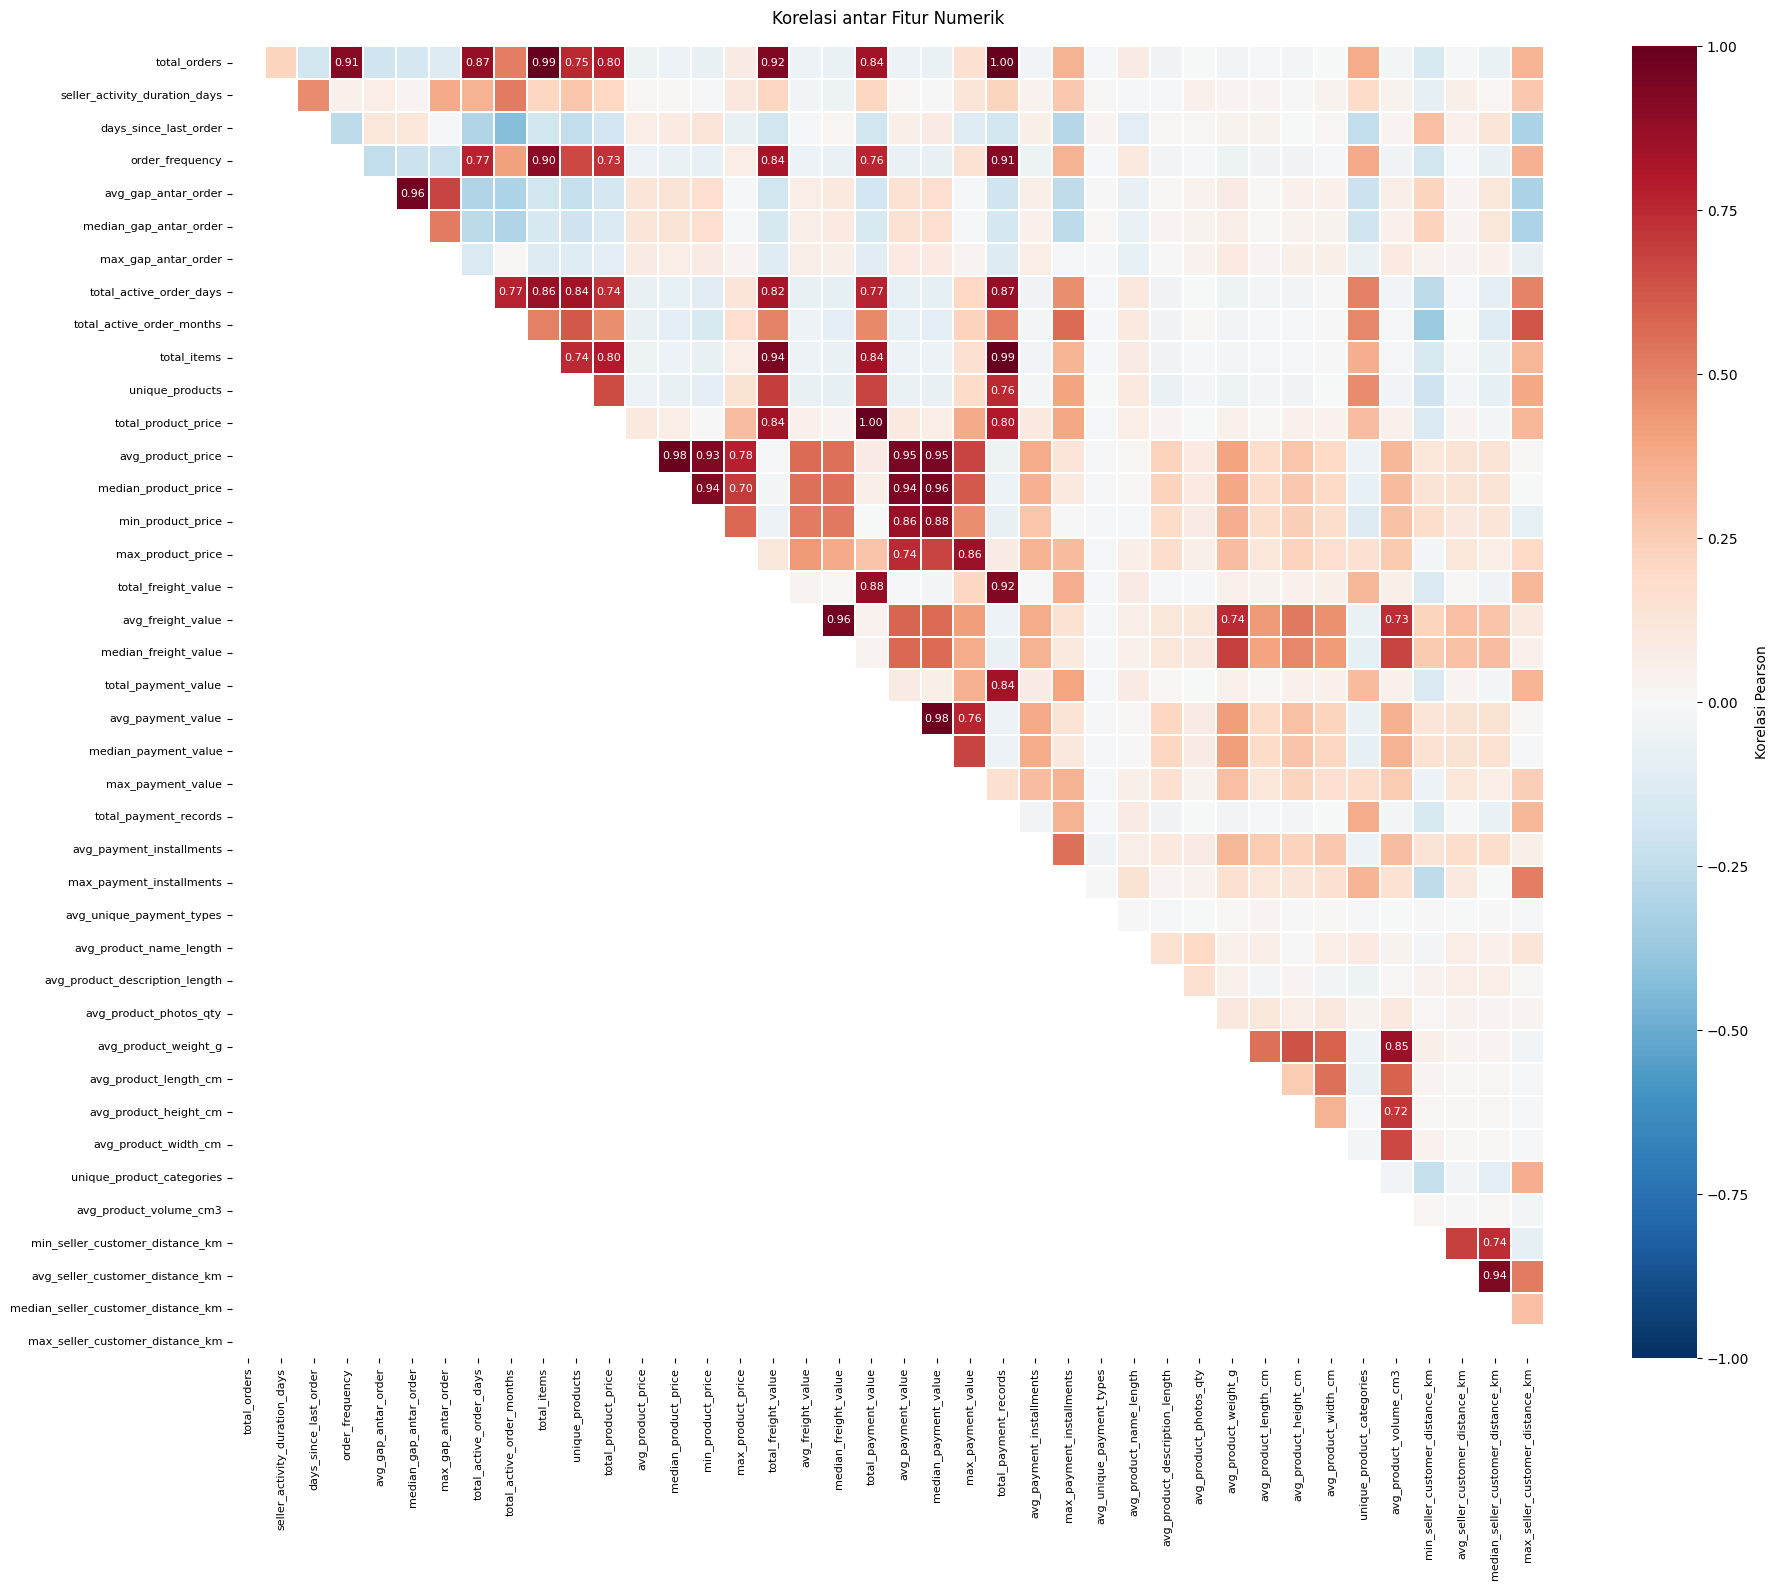

,fitur_1,fitur_2,korelasi,abs_korelasi
22,total_orders,total_payment_records,0.999674,0.999674
381,total_product_price,total_payment_value,0.995909,0.995909
8,total_orders,total_items,0.993304,0.993304
328,total_items,total_payment_records,0.993094,0.993094
402,avg_product_price,median_product_price,0.984800,0.984800
590,avg_payment_value,median_payment_value,0.983571,0.983571
150,avg_gap_antar_order,median_gap_antar_order,0.964514,0.964514
527,avg_freight_value,median_freight_value,0.962005,0.962005
436,median_product_price,median_payment_value,0.959070,0.959070
409,avg_product_price,avg_payment_value,0.952156,0.952156


In [98]:
X_num = df_model.drop(columns="churn_status").select_dtypes(include="number")
corr = X_num.corr()

mask = np.tril(np.ones_like(corr, dtype=bool))

labels = corr.map(lambda x: f"{x:.2f}" if abs(x) >= 0.7 else "")

fig, ax = plt.subplots(figsize=(20, 16))
sns.heatmap(
    corr,
    mask=mask,
    annot=labels,
    fmt="",
    cmap="RdBu_r",
    vmin=-1, vmax=1, center=0,
    square=True,
    linewidths=0.3,
    annot_kws={"size": 8},
    cbar_kws={"label": "Korelasi Pearson"},
    ax=ax
)
ax.set_title("Korelasi antar Fitur Numerik", pad=16)
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()


upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

pasangan_kuat = (
    upper.stack()
    .rename("korelasi")
    .reset_index()
    .rename(columns={"level_0": "fitur_1", "level_1": "fitur_2"})
)

pasangan_kuat = pasangan_kuat[
    pasangan_kuat["korelasi"].abs() >= 0.5
].copy()

pasangan_kuat["abs_korelasi"] = pasangan_kuat["korelasi"].abs()
display(pasangan_kuat.sort_values("abs_korelasi", ascending=False))

---
## **9. Define Features & Target**

In [99]:
# Fitur
X = df_model[['total_orders',
       'days_since_last_order',
       'avg_gap_antar_order',
       'total_active_order_days',
       'unique_products',
       'total_product_price',
       'min_product_price',
       'max_payment_value',
       'max_payment_installments',
       'avg_product_name_length',
       'unique_product_categories',
       'min_seller_customer_distance_km',
       'median_seller_customer_distance_km',
       'max_seller_customer_distance_km']]
X.head()

,total_orders,days_since_last_order,avg_gap_antar_order,total_active_order_days,unique_products,total_product_price,min_product_price,max_payment_value,max_payment_installments,avg_product_name_length,unique_product_categories,min_seller_customer_distance_km,median_seller_customer_distance_km,max_seller_customer_distance_km
0,3,296.221840,10.470822,3,1,2685.00,895.0,916.02,10,40.000000,1,417.373963,687.896184,714.419890
1,200,30.261435,2.603878,126,11,25080.03,69.9,735.96,10,37.272727,2,15.215576,736.794692,2531.005836
2,51,121.858796,4.183134,39,24,1234.50,9.9,182.92,5,54.125000,1,85.122545,362.441972,2124.553351
3,1,240.002361,NaN,1,1,120.00,120.0,139.38,3,NaN,0,936.523276,936.523276,936.523276
4,158,97.137130,2.944323,111,88,19712.71,47.9,652.34,11,57.000000,1,43.284401,549.078342,2292.303810


In [100]:
# Target
y = df_model['churn_status']
y.head()

,churn_status
0,1
1,1
2,1
3,1
4,1


In [101]:
display(X , y)

,total_orders,days_since_last_order,avg_gap_antar_order,total_active_order_days,unique_products,total_product_price,min_product_price,max_payment_value,max_payment_installments,avg_product_name_length,unique_product_categories,min_seller_customer_distance_km,median_seller_customer_distance_km,max_seller_customer_distance_km
0,3,296.221840,10.470822,3,1,2685.00,895.00,916.02,10,40.000000,1,417.373963,687.896184,714.419890
1,200,30.261435,2.603878,126,11,25080.03,69.90,735.96,10,37.272727,2,15.215576,736.794692,2531.005836
2,51,121.858796,4.183134,39,24,1234.50,9.90,182.92,5,54.125000,1,85.122545,362.441972,2124.553351
3,1,240.002361,NaN,1,1,120.00,120.00,139.38,3,NaN,0,936.523276,936.523276,936.523276
4,158,97.137130,2.944323,111,88,19712.71,47.90,652.34,11,57.000000,1,43.284401,549.078342,2292.303810
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2687,26,9.285741,6.506401,23,14,1569.11,24.90,262.38,5,55.142857,7,9.462623,324.217516,2356.890930
2688,17,12.165602,32.004724,15,11,2001.60,13.00,625.74,10,48.363636,2,3.283441,338.399959,1160.528977
2689,14,60.244769,19.516766,12,3,1839.86,89.99,207.97,10,57.000000,1,231.102386,441.685496,2899.481452
2690,58,3.230185,6.651427,46,28,8776.50,39.80,690.32,10,43.750000,3,32.804723,405.316639,2568.191225


,churn_status
0,1
1,1
2,1
3,1
4,1
...,...
2687,0
2688,0
2689,1
2690,0


---
## **10. Split Data**

Tujuan data splitting adalah untuk mengevaluasi kemampuan model klasifikasi dalam melakukan prediksi pada data yang belum pernah digunakan selama proses training. Jika seluruh data digunakan untuk training, model dapat menghasilkan performa yang sangat tinggi pada data training, tetapi performanya belum tentu sama ketika diterapkan pada data baru. Kondisi tersebut dapat mengindikasikan terjadinya overfitting.

Pada proses pemodelan ini, dataset akan dibagi menjadi 80% data training dan 20% data testing. Selain itu, parameter stratify digunakan untuk menjaga agar proporsi kelas target pada data training dan testing tetap relatif sama dengan proporsi pada dataset awal.

In [102]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [103]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2153, 14)
(539, 14)
(2153,)
(539,)


---
## **11. Data Preprocessing (Feature Engineering)**

Preprocessing (Feature Engineering) merupakan proses mempersiapkan dan mengubah data sebelum digunakan dalam pemodelan dengan tujuan memastikan data memiliki kualitas dan format yang sesuai untuk algoritma machine learning. Beberapa proses preprocessing yang umum dilakukan antara lain penanganan missing value, categorical encoding, data scaling, dan feature transformation. Pada preprocessing ini, karena seluruh fitur yang digunakan merupakan fitur numerik, proses yang diterapkan adalah **penanganan missing value** dan **data scaling**.

1. **Penanganan Missing Value**
   - Penanganan missing value dilakukan karena beberapa fitur numerik memiliki nilai yang tidak tersedia.
   - Missing value pada fitur numerik diimputasi menggunakan **median** dari masing-masing fitur.
   - Median dipilih karena lebih robust terhadap outlier dan distribusi data yang skewed.

2. **Scaling Data**
   - Scaling dilakukan untuk menyamakan skala fitur numerik sehingga perbedaan rentang nilai antarfitur tidak memberikan pengaruh yang tidak proporsional terhadap proses pemodelan.
   - Karena terdapat fitur numerik yang memiliki outlier, sehingga digunakan **RobustScaler**.
   - Metode ini menggunakan median dan interquartile range (IQR), sehingga lebih robust terhadap pengaruh outlier dibandingkan metode scaling yang berbasis mean dan standar deviasi.

In [104]:
numeric_features = [
    'total_orders',
    'days_since_last_order',
    'avg_gap_antar_order',
    'total_active_order_days',
    'unique_products',
    'total_product_price',
    'min_product_price',
    'max_payment_value',
    'max_payment_installments',
    'avg_product_name_length',
    'unique_product_categories',
    'min_seller_customer_distance_km',
    'median_seller_customer_distance_km',
    'max_seller_customer_distance_km'
]

In [106]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', RobustScaler())
            ]),
            numeric_features
        ),
    ]
)

preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', RobustScaler())]),
                                 ['total_orders', 'days_since_last_order',
                                  'avg_gap_antar_order',
                                  'total_active_order_days', 'unique_products',
                                  'total_product_price', 'min_product_price',
                                  'max_payment_value',
                                  'max_payment_installments',
                                  'avg_product_name_length',
                                  'unique_product_categories',
                                  'min_seller_customer_distance_km',
                                  'median_seller_customer_distance_km',
                                  'max_seller_customer_distance_km'])])

In [107]:
X_train_processed = preprocessor.fit_transform(X_train)
X_train_processed = pd.DataFrame(X_train_processed,columns=preprocessor.get_feature_names_out(),index=X_train.index)
X_train_processed.head()

,num__total_orders,num__days_since_last_order,num__avg_gap_antar_order,num__total_active_order_days,num__unique_products,num__total_product_price,num__min_product_price,num__max_payment_value,num__max_payment_installments,num__avg_product_name_length,num__unique_product_categories,num__min_seller_customer_distance_km,num__median_seller_customer_distance_km,num__max_seller_customer_distance_km
2216,0.333333,-0.247449,-0.236321,0.473684,0.000000,0.436865,1.040521,0.223111,1.500000,-0.724170,1.0,-0.023676,-0.069587,0.660950
1028,-0.125000,-0.248218,0.679885,-0.105263,0.111111,0.548455,0.969754,1.752651,-0.500000,0.744890,0.0,-0.217421,-0.042921,-0.175656
2490,0.458333,-0.242569,-0.071886,0.368421,0.222222,0.510590,0.260637,-0.069222,0.333333,0.302592,0.0,-0.185258,0.214990,0.533546
2064,-0.291667,3.048499,0.000000,-0.315789,-0.333333,-0.263622,-0.174964,-0.587904,-1.166667,-0.013335,0.0,0.873109,-0.248947,-0.732239
2432,-0.250000,0.005291,1.041287,-0.263158,-0.222222,-0.241651,-0.347178,-0.389311,-1.166667,-0.961115,0.0,-0.142007,-1.100670,-0.890082


---
## **12. Model & Evaluation**

### **12.1. Default Modeling**

Pada tahap ini, belum diketahui model yang memiliki performa terbaik, sehingga beberapa model akan diuji menggunakan parameter default untuk membandingkan performanya dan menentukan model yang paling sesuai dengan dataset.

In [108]:
# Base Model
tree = DecisionTreeClassifier(random_state=42)
logreg = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()

# Ensemble — Various Type
voting_clf_H = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('knn', knn),
        ('tree', tree)],
    voting='hard')

voting_clf_S = VotingClassifier(
    estimators=[
        ('logreg', logreg),
        ('knn', knn),
        ('tree', tree)],
    voting='soft')

stacking_clf = StackingClassifier(
    estimators=[
        ('logreg', logreg),
        ('knn', knn),
        ('tree', tree)],
    final_estimator=logreg)

# Ensemble — Similar Type
## Bagging
bagging_clf = BaggingClassifier(estimator=tree,random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
## Boosting:
gradboost = GradientBoostingClassifier(random_state=42)
adaboost = AdaBoostClassifier(random_state=42)
catboost = CatBoostClassifier(random_state=42)
xgboost = XGBClassifier(random_state=42)
lgbm = LGBMClassifier(random_state=42)

In [109]:
models = {
    'Logistic Regression': logreg,
    'KNN': knn,
    'Decision Tree': tree,
    'Hard Voting': voting_clf_H,
    'Soft Voting': voting_clf_S,
    'Stacking': stacking_clf,
    'Bagging': bagging_clf,
    'Random Forest': rf_clf,
    'Gradient Boosting': gradboost,
    'AdaBoost': adaboost,
    'CatBoost': catboost,
    'XGBoost': xgboost,
    'LightGBM': lgbm
    }

scoring = {
    'f2': make_scorer(fbeta_score, beta=2, pos_label=1),
    'recall': make_scorer(recall_score, pos_label=1)
}

results = []

for name, model in models.items():
    model_pipeline = Pipeline([
        ('preprocess', preprocessor),
        ('model', model)
    ])

    cv_results = cross_validate(
        model_pipeline,
        X_train,
        y_train,
        cv=5,
        scoring=scoring,
        return_train_score=True
    )

    results.append({
        'Model': name,
        'Train F2': cv_results['train_f2'].round(3),
        'Validation F2': cv_results['test_f2'].round(3),
        'Mean Train F2': cv_results['train_f2'].mean().round(3),
        'Mean Validation F2': cv_results['test_f2'].mean().round(3),
        'Std Validation F2': cv_results['test_f2'].std().round(3),
        'Train Recall': cv_results['train_recall'].round(3),
        'Validation Recall': cv_results['test_recall'].round(3),
        'Mean Train Recall': cv_results['train_recall'].mean().round(3),
        'Mean Validation Recall': cv_results['test_recall'].mean().round(3),
        'Std Validation Recall': cv_results['test_recall'].std().round(3)
    })

Streaming output truncated to the last 5000 lines.
39:	learn: 0.4641246	total: 199ms	remaining: 4.77s
40:	learn: 0.4610230	total: 202ms	remaining: 4.73s
41:	learn: 0.4585056	total: 206ms	remaining: 4.7s
42:	learn: 0.4552358	total: 210ms	remaining: 4.68s
43:	learn: 0.4523937	total: 214ms	remaining: 4.65s
44:	learn: 0.4494978	total: 218ms	remaining: 4.62s
45:	learn: 0.4475522	total: 222ms	remaining: 4.6s
46:	learn: 0.4445589	total: 226ms	remaining: 4.59s
47:	learn: 0.4413755	total: 230ms	remaining: 4.56s
48:	learn: 0.4389450	total: 233ms	remaining: 4.53s
49:	learn: 0.4363711	total: 237ms	remaining: 4.5s
50:	learn: 0.4340869	total: 241ms	remaining: 4.48s
51:	learn: 0.4317817	total: 244ms	remaining: 4.45s
52:	learn: 0.4300006	total: 248ms	remaining: 4.43s
53:	learn: 0.4276696	total: 251ms	remaining: 4.4s
54:	learn: 0.4252199	total: 255ms	remaining: 4.38s
55:	learn: 0.4229409	total: 259ms	remaining: 4.36s
56:	learn: 0.4208648	total: 263ms	remaining: 4.34s
57:	learn: 0.4194787	total: 266ms	r

In [110]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by='Mean Validation F2',
    ascending=False
)

,Model,Train F2,Validation F2,Mean Train F2,Mean Validation F2,Std Validation F2,Train Recall,Validation Recall,Mean Train Recall,Mean Validation Recall,Std Validation Recall
7,Random Forest,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.879, 0.867, 0.874, 0.877, 0.877]",1.000,0.875,0.004,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.89, 0.873, 0.887, 0.879, 0.88]",1.000,0.882,0.006
10,CatBoost,"[0.979, 0.98, 0.971, 0.977, 0.976]","[0.885, 0.866, 0.867, 0.861, 0.871]",0.976,0.870,0.008,"[0.982, 0.984, 0.973, 0.982, 0.98]","[0.9, 0.866, 0.873, 0.855, 0.869]",0.980,0.873,0.015
12,LightGBM,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.887, 0.853, 0.863, 0.868, 0.869]",1.000,0.868,0.011,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.904, 0.856, 0.869, 0.862, 0.876]",1.000,0.873,0.017
8,Gradient Boosting,"[0.938, 0.933, 0.931, 0.938, 0.926]","[0.884, 0.875, 0.85, 0.862, 0.863]",0.933,0.867,0.012,"[0.942, 0.936, 0.934, 0.945, 0.926]","[0.893, 0.883, 0.856, 0.859, 0.859]",0.937,0.870,0.015
5,Stacking,"[0.899, 0.894, 0.896, 0.903, 0.896]","[0.877, 0.876, 0.865, 0.851, 0.863]",0.898,0.866,0.010,"[0.899, 0.898, 0.897, 0.906, 0.897]","[0.883, 0.88, 0.869, 0.845, 0.863]",0.899,0.868,0.014
0,Logistic Regression,"[0.863, 0.863, 0.863, 0.866, 0.862]","[0.868, 0.88, 0.861, 0.841, 0.856]",0.864,0.861,0.013,"[0.86, 0.862, 0.859, 0.864, 0.857]","[0.869, 0.883, 0.863, 0.828, 0.852]",0.861,0.859,0.019
3,Hard Voting,"[0.936, 0.934, 0.935, 0.938, 0.935]","[0.856, 0.859, 0.875, 0.85, 0.864]",0.936,0.861,0.008,"[0.939, 0.937, 0.938, 0.942, 0.939]","[0.856, 0.859, 0.883, 0.845, 0.866]",0.939,0.862,0.013
9,AdaBoost,"[0.85, 0.86, 0.872, 0.887, 0.869]","[0.863, 0.856, 0.867, 0.853, 0.852]",0.868,0.858,0.006,"[0.838, 0.854, 0.874, 0.89, 0.868]","[0.856, 0.849, 0.869, 0.848, 0.852]",0.865,0.855,0.008
11,XGBoost,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.868, 0.855, 0.863, 0.851, 0.844]",1.000,0.856,0.009,"[1.0, 1.0, 1.0, 1.0, 1.0]","[0.883, 0.859, 0.873, 0.845, 0.842]",1.000,0.860,0.016
4,Soft Voting,"[0.987, 0.987, 0.99, 0.989, 0.989]","[0.859, 0.851, 0.868, 0.823, 0.824]",0.988,0.845,0.018,"[0.991, 0.99, 0.993, 0.993, 0.992]","[0.869, 0.856, 0.88, 0.814, 0.818]",0.992,0.847,0.027


Dari beberapa model yang sudah dijalankan model yang memiliki mean validation F2 score tertinggi adalah model random forest, namun pemilihan model terbaik juga ditentukan berdasarkan keseimbangan antara train dan validation, sehingga kami memilih **logistic regression** karena memiliki nilai F2 Score yang lebih seimbang antara train dan validationnya serta standar deviasi yang rendah.

### **12.2 Hyperparameter Tuning**

Hyperparameter Tuning adalah proses mencari kombinasi parameter model yang optimal untuk mendapatkan performa terbaik. Proses ini dilakukan dengan mencoba berbagai kombinasi nilai hyperparameter dan membandingkan performanya. Pada proses tuning ini digunakan **GridSearchCV** karena dapat menguji seluruh kombinasi hyperparameter yang telah ditentukan secara sistematis, sehingga kombinasi terbaik dapat ditemukan berdasarkan F2-score. Selain itu, GridSearchCV digunakan karena jumlah kombinasi hyperparameter yang diuji relatif sedikit, sehingga seluruh kombinasi dapat dievaluasi tanpa beban komputasi yang terlalu besar.  

#### **Logistic Regression Tuning**

Logistic Regression merupakan algoritma **supervised learning** yang digunakan untuk binary classification. Model menghitung kombinasi berbobot dari setiap fitur, kemudian menggunakan fungsi sigmoid untuk menghasilkan probabilitas antara 0 dan 1. Pada kasus churn, probabilitas tersebut digunakan untuk menentukan apakah customer diprediksi Churn (1) atau No Churn (0) berdasarkan threshold tertentu.

Pada proses *hyperparameter tuning*, parameter yang digunakan adalah **`C`** (inverse regularization strength), yang berfungsi untuk mengatur kekuatan regularisasi pada model. Nilai **`C`** memiliki hubungan terbalik dengan kekuatan regularisasi, sehingga semakin kecil nilai **`C`**, semakin kuat regularisasi yang diterapkan. Regularisasi digunakan untuk membatasi kompleksitas model dan mengurangi risiko overfitting. Beberapa nilai **`C`** diuji menggunakan **GridSearchCV** dengan **5-fold cross-validation**, kemudian dipilih nilai yang menghasilkan rata-rata F2-score validasi tertinggi. Penggunaan parameter **`C`** penting karena model diharapkan tidak hanya memiliki performa baik pada data training, tetapi juga mampu melakukan generalisasi dengan baik pada data yang belum pernah digunakan.

Model cenderung dapat dipercaya ketika pola hubungan antara fitur dan target relatif sederhana, data yang digunakan bersih dan relevan, serta data baru memiliki karakteristik yang serupa dengan data training. Performa model juga perlu konsisten pada data validasi dan tidak menunjukkan indikasi overfitting yang tinggi. Logistic Regression memiliki keterbatasan dalam menangkap hubungan yang kompleks dan non-linear antarfitur. Model juga menjadi kurang akurat ketika terdapat fitur penting yang tidak tersedia atau karakteristik data baru berbeda jauh dari data training. Selain itu, meskipun regularisasi melalui parameter **`C`** dapat **membantu mengurangi overfitting**, regularisasi yang terlalu kuat juga dapat membuat model terlalu sederhana sehingga pola penting pada data tidak dapat dipelajari dengan baik.

In [112]:
f2 = make_scorer(fbeta_score, beta=2)

pipe_logreg = Pipeline([
    ('preprocess', preprocessor),
    ('model', logreg)])

param_grid_logreg = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100]}

gscv_logreg = GridSearchCV(
    estimator=pipe_logreg,
    param_grid=param_grid_logreg,
    scoring=f2,
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True)

gscv_logreg.fit(X_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          RobustScaler())]),
                                                                         ['total_orders',
                                                                          'days_since_last_order',
                                                                          'avg_gap_antar_order',
                                                                          'total_active_order_days',
                                                                          'unique_products',
                                                                          'total_product_price',
                                                                          'min_product_price',
                                                                          'max_payment_val...
                                                                          'avg_product_name_length',
                                                                          'unique_product_categories',
                                                                          'min_seller_customer_distance_km',
                                                                          'median_seller_customer_distance_km',
                                                                          'max_seller_customer_distance_km'])])),
                                       ('model',
                                        LogisticRegression(random_state=42))]),
             n_jobs=-1, param_grid={'model__C': [0.001, 0.01, 0.1, 1, 10, 100]},
             return_train_score=True,
             scoring=make_scorer(fbeta_score, response_method='predict', beta=2),
             verbose=2)

In [113]:
logreg_results = pd.DataFrame(gscv_logreg.cv_results_).sort_values(by='mean_test_score', ascending=False).reset_index(drop=True)
logreg_results[['param_model__C', 'mean_train_score', 'mean_test_score', 'std_test_score']]

,param_model__C,mean_train_score,mean_test_score,std_test_score
0,0.001,0.904795,0.904130,0.008853
1,0.010,0.892814,0.892703,0.007799
2,0.100,0.873691,0.868106,0.005740
3,1.000,0.863555,0.861281,0.012982
4,10.000,0.860272,0.854791,0.014227
5,100.000,0.860248,0.854675,0.014287


In [114]:
print("Best Parameter:", gscv_logreg.best_params_)
print("Best CV F2:", gscv_logreg.best_score_)

Best Parameter: {'model__C': 0.001}
Best CV F2: 0.9041297313306071


---
## **13. Final Model Evaluation**

In [115]:
gscv_logreg.fit(X_train, y_train)

best_model = gscv_logreg.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)

train_f2 = fbeta_score(y_train, y_train_pred, beta=2)
test_f2 = fbeta_score(y_test, y_test_pred, beta=2)

print("Best Parameter :", gscv_logreg.best_params_)
print("Train F2       :", train_f2)
print("Best CV F2     :", gscv_logreg.best_score_)
print("Test F2        :", test_f2)

print("\nClassification Report:")
print(classification_report(y_test, y_test_pred))

cm = confusion_matrix(y_test, y_test_pred)
print("\nConfusion Matrix:")
print(cm)

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameter : {'model__C': 0.001}
Train F2       : 0.904359141184125
Best CV F2     : 0.9041297313306071
Test F2        : 0.8961038961038961

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.29      0.42       175
           1       0.74      0.95      0.83       364

    accuracy                           0.73       539
   macro avg       0.73      0.62      0.62       539
weighted avg       0.73      0.73      0.69       539


Confusion Matrix:
[[ 51 124]
 [ 19 345]]


In [116]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()

accuracy = accuracy_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
fpr = fp / (fp + tn)
fnr = fn / (fn + tp)

print("\nFinal Model Evaluation:")
print(f"- True Prediction (Accuracy)    : {accuracy * 100:.2f}%")
print(f"- True Positive Rate (Recall)   : {recall * 100:.2f}%")
print(f"- Precision                     : {precision * 100:.2f}%")
print(f"- False Positive Rate           : {fpr * 100:.2f}%")
print(f"- False Negative Rate           : {fnr * 100:.2f}%")


Final Model Evaluation:
- True Prediction (Accuracy)    : 73.47%
- True Positive Rate (Recall)   : 94.78%
- Precision                     : 73.56%
- False Positive Rate           : 70.86%
- False Negative Rate           : 5.22%


---
## **14. Cost Benefit Analysis**

Cost-Benefit Analysis dilakukan untuk membandingkan estimasi kerugian perusahaan pada dua skema strategi retensi seller, yaitu **Without Model** sebagai baseline dan **With Machine Learning** sebagai strategi retensi berbasis prediksi churn.

Pada skema **Without Model**, perusahaan tidak menggunakan model prediksi untuk menentukan seller yang perlu diberikan tindakan retensi. Dalam analisis ini diasumsikan tidak ada seller yang diberikan promosi, sehingga tidak terdapat biaya False Positive (FP). Namun, seller yang sebenarnya churn tidak mendapatkan tindakan retensi dan dikategorikan sebagai False Negative (FN).

Pada skema **With Machine Learning**, pemberian promosi dilakukan berdasarkan hasil prediksi model. seller yang diprediksi berisiko churn diberikan tindakan retensi, sehingga terdapat kemungkinan False Positive, yaitu seller yang sebenarnya tidak churn tetapi mendapatkan promosi.

Untuk menghitung estimasi kerugian, digunakan asumsi biaya sebagai berikut:

- **False Negative (FN) = `$500`**, yaitu potensi kerugian ketika seller yang sebenarnya churn tidak mendapatkan tindakan retensi.
- **False Positive (FP) = `$100`**, yaitu biaya promosi yang diberikan kepada seller yang sebenarnya tidak churn.

Berdasarkan confusion matrix `[[51, 124], [19, 345]]`, diperoleh **19 FN** dan **124 FP**. Total kerugian kemudian dihitung menggunakan rumus:

***Loss = Cost Acquisition × FN + Cost Retention × FP***

- Berdasarkan asumsi biaya yang digunakan, skema **With Machine Learning** menghasilkan estimasi kerugian sebesar **`$21,900`**, lebih rendah dibandingkan skema **Without Model** sebesar **`$182,000`**. Dengan demikian, penggunaan **With Machine Learning** menghasilkan pengurangan estimasi kerugian sebesar 87.97%, atau skema **Without Model** memiliki estimasi kerugian sekitar 8.31 kali lebih besar dibandingkan skema With Machine Learning.

- Perbedaan tersebut terutama disebabkan oleh penurunan jumlah **False Negative** dari 364 menjadi 19. Meskipun penggunaan machine learning menghasilkan 124 False Positive karena terdapat seller yang mendapatkan promosi tetapi sebenarnya tidak churn, biaya tersebut masih lebih rendah dibandingkan potensi kerugian akibat seller churn yang tidak mendapatkan tindakan retensi.
- Dengan demikian, berdasarkan asumsi biaya dalam analisis ini, machine learning dapat membantu perusahaan melakukan **targeted retention**, yaitu memberikan tindakan retensi kepada seller berdasarkan risiko churn yang diprediksi oleh model, dibandingkan tidak melakukan tindakan retensi sama sekali.
- Perlu diperhatikan bahwa hasil cost-benefit bergantung pada asumsi biaya FN dan FP yang digunakan. Oleh karena itu, hasil ini menunjukkan estimasi berdasarkan skenario biaya yang ditetapkan dan bukan merupakan nilai kerugian aktual perusahaan.

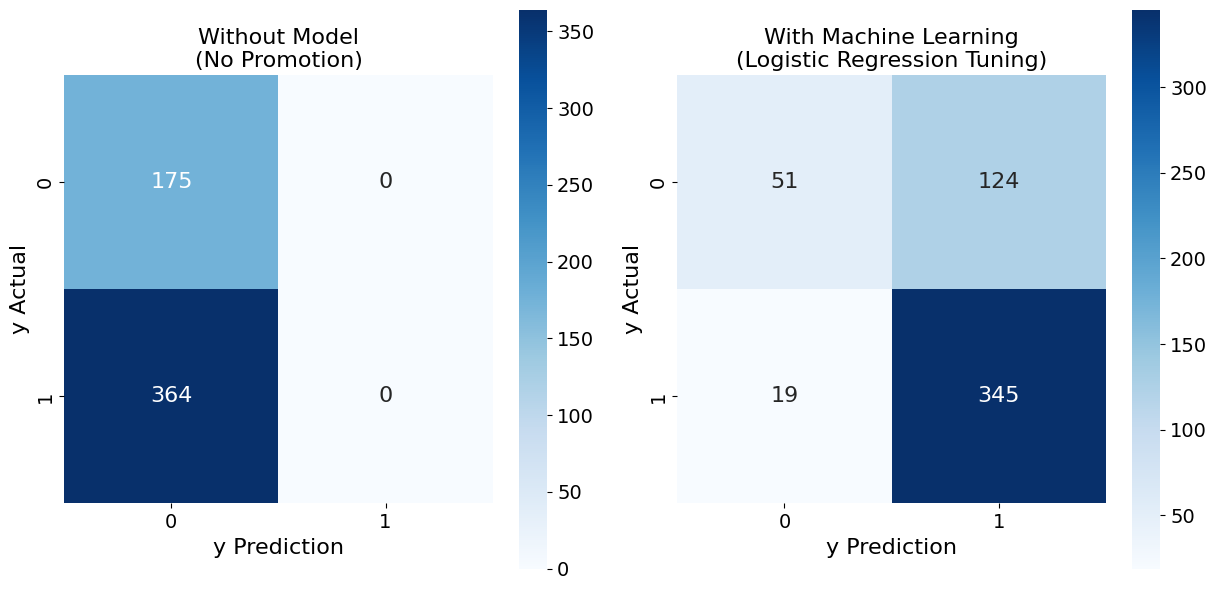

In [ ]:
# Confusion Matrix

# With Model Logistic Regression
cm_ml = np.array([
    [51, 124],
    [19, 345]])

# Without Model
# TN = 175, FP = 0
# FN = 364, TP = 0
cm_without_model_2 = np.array([
    [175, 0],
    [364, 0]])

plt.figure(figsize=(18, 6))

# Without Model
plt.subplot(1, 3, 2)
sns.heatmap(cm_without_model_2, annot=True, fmt='.0f', square=True, cmap="Blues", annot_kws={"size": 16})
plt.gca().collections[0].colorbar.ax.tick_params(labelsize=14)
plt.xlabel('y Prediction', fontsize=16)
plt.ylabel('y Actual', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('Without Model\n(No Promotion)', fontsize=16)

# With Model Logistic Regression
plt.subplot(1, 3, 3)
sns.heatmap(cm_ml, annot=True, fmt='.0f', square=True, cmap="Blues", annot_kws={"size": 16})
plt.gca().collections[0].colorbar.ax.tick_params(labelsize=14)
plt.xlabel('y Prediction', fontsize=16)
plt.ylabel('y Actual', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title('With Machine Learning\n(Logistic Regression Tuning)', fontsize=16)

plt.tight_layout()
plt.show()

---
## **15. Churn Prediction Model Interpretability**

### **Fitur Koefisien**

**Logistic Regression** ini merupakan model interpretable, sehingga pengaruh setiap fitur dapat dianalisis menggunakan **koefisien (`coefficients`)** yang dihasilkan oleh model. Nilai koefisien menunjukkan arah dan besarnya pengaruh suatu fitur terhadap probabilitas **Churn**.

Koefisien bernilai **positif** menunjukkan bahwa peningkatan nilai fitur cenderung meningkatkan kemungkinan customer mengalami churn, sedangkan koefisien **negatif** menunjukkan kecenderungan menurunkan kemungkinan churn. Semakin besar **nilai absolut koefisien**, semakin besar pengaruh relatif fitur tersebut terhadap prediksi model.


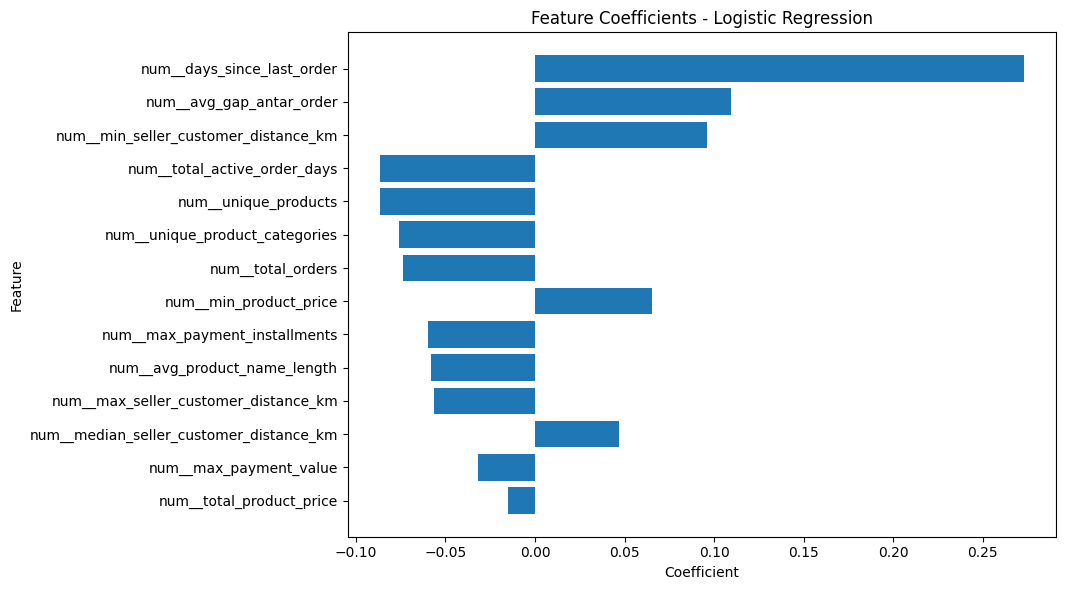

In [134]:
coefficients = best_model.named_steps['model'].coef_[0]
feature_names = best_model.named_steps['preprocess'].get_feature_names_out()

df_coefficients = pd.DataFrame({
    'feature': feature_names,
    'coefficient': coefficients,
    'abs_coefficient': np.abs(coefficients)
}).sort_values(by='abs_coefficient', ascending=False)

plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 2)
plt.barh(df_coefficients['feature'], df_coefficients['coefficient'])
plt.xlabel('Coefficient')
plt.ylabel('Feature')
plt.title('Feature Coefficients - Logistic Regression')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

---
## **16. Save Final Model**

In [118]:
model_final = gscv_logreg.best_estimator_
model_final.fit(X, y)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['total_orders',
                                                   'days_since_last_order',
                                                   'avg_gap_antar_order',
                                                   'total_active_order_days',
                                                   'unique_products',
                                                   'total_product_price',
                                                   'min_product_price',
                                                   'max_payment_value',
                                                   'max_payment_installments',
                                                   'avg_product_name_length',
                                                   'unique_product_categories',
                                                   'min_seller_customer_distance_km',
                                                   'median_seller_customer_distance_km',
                                                   'max_seller_customer_distance_km'])])),
                ('model', LogisticRegression(C=0.001, random_state=42))])

In [119]:
pickle.dump(model_final, open('olist_seller_churn_model_final.sav', 'wb'))

---
## **17. Load Sav Model to Predict Data**

In [121]:
model_load = pickle.load(open('olist_seller_churn_model_final.sav', 'rb'))
model_load

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   RobustScaler())]),
                                                  ['total_orders',
                                                   'days_since_last_order',
                                                   'avg_gap_antar_order',
                                                   'total_active_order_days',
                                                   'unique_products',
                                                   'total_product_price',
                                                   'min_product_price',
                                                   'max_payment_value',
                                                   'max_payment_installments',
                                                   'avg_product_name_length',
                                                   'unique_product_categories',
                                                   'min_seller_customer_distance_km',
                                                   'median_seller_customer_distance_km',
                                                   'max_seller_customer_distance_km'])])),
                ('model', LogisticRegression(C=0.001, random_state=42))])

In [130]:
# Mengambil Sampel
X_sample = X_test.sample(10)
X_sample

,total_orders,days_since_last_order,avg_gap_antar_order,total_active_order_days,unique_products,total_product_price,min_product_price,max_payment_value,max_payment_installments,avg_product_name_length,unique_product_categories,min_seller_customer_distance_km,median_seller_customer_distance_km,max_seller_customer_distance_km
2050,9,47.151019,28.843676,8,9,5279.91,329.99,1017.52,10,40.666667,1,27.805525,324.994640,2155.661459
2387,7,158.017350,14.336667,6,4,671.50,39.00,161.69,4,39.333333,2,580.022534,654.279041,2024.359528
304,3,255.093600,151.505434,3,3,3747.00,549.00,2023.00,10,51.000000,2,1834.686549,2774.892918,2876.849531
1501,1,178.219132,NaN,1,1,69.00,69.00,97.88,1,50.000000,1,843.030751,843.030751,843.030751
2131,4,61.204491,76.242388,4,3,259.03,44.30,91.33,1,46.000000,3,3.466902,1033.356338,1534.460107
2557,1,362.988507,NaN,1,1,69.90,69.90,78.01,7,30.000000,1,3.234848,3.234848,3.234848
974,38,13.291296,10.372314,36,17,9397.54,49.49,625.86,10,57.117647,5,34.380352,277.500038,2046.593866
919,2,3.264213,554.746991,2,2,734.80,174.90,599.05,1,46.500000,1,491.659695,508.782323,525.904951
148,4,199.128750,23.265853,4,2,696.26,71.80,419.84,6,47.000000,1,833.091434,1006.682694,1339.525137
2284,1,95.255880,NaN,1,1,168.10,168.10,205.65,4,35.000000,1,2478.641546,2478.641546,2478.641546


In [131]:
# Hasil Prediksi Sample
model_load.predict(X_sample)

array([1, 1, 1, 1, 1, 1, 0, 1, 1, 1])

In [132]:
# Melihat probabilitas tingkat churn atau tidak
model_load.predict_proba(X_sample)[:,1]

array([0.73170172, 0.76287983, 0.95439024, 0.81779454, 0.78325888,
       0.81039489, 0.48002969, 0.99029343, 0.81725578, 0.89899318])

---
## **18. Kesimpulan & Rekomendasi**

### **Kesimpulan**

Dapat disimpulkan bahwa machine learning dapat digunakan sebagai metode untuk mengidentifikasi customer yang berpotensi mengalami churn, sehingga perusahaan dapat melakukan tindakan retensi lebih efektif.
- Hasil awal model logistic regression (default parameter) menunjukkan bahwa nilai F2-score pada training 86,1% dan testing 85,9% yang dimana tidak menunjukkan indikasi overfitting.
- Hasil evaluasi model setelah dituning menggunakan grid search CV menunjukkan nilai training F2 score 90,48% (+4,38%) dan testing 90,41% (+4,51%).
- Berdasarkan interpretasi koefisien Logistic Regression, fitur dengan pengaruh terbesar days_since_last_order yang dimana hari lebih panjang meningkatkan kecenderungan seller untuk churn.
- Hasil Cost Benefit analisis menunjukkan skenario **With Machine Learning** menghasilkan estimasi loss yang rendah sebesar **`87,97%`** dibandingkan **Without Model**. Dengan demikian, implementasi machine learning berpotensi membantu perusahaan olist untuk lebih hemat.

### **Rekomendasi**

- Seller yang telah teridentifikasi Churn berdasarkan model perlu diberikan prioritas campaign.
- Model juga dapat digunakan sebagai alat pendukung pengambilan keputusan dalam menentukan seller yang akan diberikan promosi.

